In [15]:
from pathlib import Path
import pandas as pd

STATIC_PARAMETERS = {"RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}
STATIC_EXCLUDE = {"RecordID", "Age", "Gender", "Height", "ICUType"}

def hhmm_to_minutes(value: str) -> int:
    hours, minutes = value.split(":")
    return int(hours) * 60 + int(minutes)

def parse_patient_file(file_path: Path):
    df = pd.read_csv(file_path)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    record_rows = df.loc[df["Parameter"] == "RecordID", "Value"].dropna()
    patient_id = int(record_rows.iloc[0]) if not record_rows.empty else int(file_path.stem)

    static_df = df[df["Parameter"].isin(STATIC_PARAMETERS)].copy()
    static_df = static_df.drop_duplicates(subset=["Parameter"], keep="last")
    static_values = static_df.set_index("Parameter")["Value"].to_dict()

    static_record = {
        "RecordID": patient_id,
        "Age": static_values.get("Age"),
        "Gender": static_values.get("Gender"),
        "Height": static_values.get("Height"),
        "Weight": static_values.get("Weight"),
        "ICUType": static_values.get("ICUType"),
    }

    dynamic_df = df[~df["Parameter"].isin(STATIC_EXCLUDE)].copy()
    dynamic_df["Minutes"] = dynamic_df["Time"].map(hhmm_to_minutes)
    dynamic_df["RecordID"] = patient_id
    dynamic_df = dynamic_df[["RecordID", "Time", "Minutes", "Parameter", "Value"]]

    return static_record, dynamic_df

def load_cohort(folder: str):
    folder_path = Path(folder)
    static_records = []
    dynamic_tables = []

    for file_path in sorted(folder_path.glob("*.txt")):
        static_record, dynamic_df = parse_patient_file(file_path)
        static_records.append(static_record)
        dynamic_tables.append(dynamic_df)

    patients_static = pd.DataFrame(static_records).drop_duplicates(subset=["RecordID"])
    patients_static = patients_static.set_index("RecordID").sort_index()

    if dynamic_tables:
        patient_events = pd.concat(dynamic_tables, ignore_index=True)
        patient_events = patient_events.sort_values(["RecordID", "Minutes", "Parameter"]).reset_index(drop=True)
    else:
        patient_events = pd.DataFrame(columns=["RecordID", "Time", "Minutes", "Parameter", "Value"])

    return patients_static, patient_events

In [16]:
train_data_location = "set-a"
patients_static, patient_events = load_cohort(train_data_location)

print(f"Number of patients: {patients_static.shape[0]}")
print(f"Number of dynamic observations: {patient_events.shape[0]}")

display(patients_static.head())
display(patient_events.head(15))

Number of patients: 4000
Number of dynamic observations: 1737980


,Age,Gender,Height,Weight,ICUType
RecordID,,,,,
132539,54.0,0.0,-1.0,-1.0,4.0
132540,76.0,1.0,175.3,81.6,2.0
132541,44.0,0.0,-1.0,56.7,3.0
132543,68.0,1.0,180.3,84.6,3.0
132545,88.0,0.0,-1.0,-1.0,3.0


,RecordID,Time,Minutes,Parameter,Value
0,132539,00:00,0,Weight,-1.00
1,132539,00:07,7,GCS,15.00
2,132539,00:07,7,HR,73.00
3,132539,00:07,7,NIDiasABP,65.00
4,132539,00:07,7,NIMAP,92.33
5,132539,00:07,7,NISysABP,147.00
6,132539,00:07,7,RespRate,19.00
7,132539,00:07,7,Temp,35.10
8,132539,00:07,7,Urine,900.00
9,132539,00:37,37,HR,77.00


In [17]:
#create a pivot table of patient_events
pivot_table = patient_events.pivot_table(index=["RecordID", "Time", "Minutes"], columns="Parameter", values="Value")
print("Pivot table of patient_events:")
# display(pivot_table.head(5))
#find how many columns are in the pivot table
print(f"Number of columns in the pivot table: {pivot_table.shape[1]}")
#make it a dataframe again
pivot_table = pivot_table.reset_index()
print("Pivot table of patient_events after resetting index:")
# display(pivot_table.head(5))
#join the static variables to the pivot table
pivot_table = pivot_table.merge(patients_static, on="RecordID", how="left")
pivot_table = pivot_table.sort_values(["RecordID", "Minutes"]).reset_index(drop=True)
print("Pivot table of patient_events after merging with patients_static:")
# display(pivot_table.head(5))
#values that gender variable can take
print(f"Unique values in Gender column: {pivot_table['Gender'].unique()}")
#minus one for the 'Gender' 0,1,-1
print(f"Number of columns in the pivot table after merging with patients_static: {pivot_table.shape[1]}")
print(f"pivot table columns: {pivot_table.columns.tolist()}")

Pivot table of patient_events:
Number of columns in the pivot table: 37
Pivot table of patient_events after resetting index:
Pivot table of patient_events after merging with patients_static:
Unique values in Gender column: [ 0.  1. -1.]
Number of columns in the pivot table after merging with patients_static: 45
pivot table columns: ['RecordID', 'Time', 'Minutes', 'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight_x', 'pH', 'Age', 'Gender', 'Height', 'Weight_y', 'ICUType']


In [18]:
pivot_table

,RecordID,Time,Minutes,ALP,ALT,AST,Albumin,BUN,Bilirubin,Cholesterol,...,TroponinT,Urine,WBC,Weight_x,pH,Age,Gender,Height,Weight_y,ICUType
0,132539,00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-1.0,NaN,54.0,0.0,-1.0,-1.0,4.0
1,132539,00:07,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,900.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
2,132539,00:37,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,60.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
3,132539,01:37,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,30.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
4,132539,02:37,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,170.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299259,142673,45:36,2736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,23.0,NaN,87.3,NaN,78.0,0.0,157.5,87.3,4.0
299260,142673,45:39,2739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.31,78.0,0.0,157.5,87.3,4.0
299261,142673,46:36,2796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,40.0,NaN,87.3,NaN,78.0,0.0,157.5,87.3,4.0
299262,142673,47:21,2841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,87.3,NaN,78.0,0.0,157.5,87.3,4.0


In [19]:
#find unique parameters in patient_events
unique_parameters = patient_events["Parameter"].unique()
print(f"Unique parameters in patient_events: {unique_parameters}")
print(f"length of unique parameters: {len(unique_parameters)}")

Unique parameters in patient_events: ['Weight' 'GCS' 'HR' 'NIDiasABP' 'NIMAP' 'NISysABP' 'RespRate' 'Temp'
 'Urine' 'HCT' 'BUN' 'Creatinine' 'Glucose' 'HCO3' 'K' 'Mg' 'Na'
 'Platelets' 'WBC' 'PaCO2' 'PaO2' 'pH' 'DiasABP' 'FiO2' 'MAP' 'MechVent'
 'SysABP' 'SaO2' 'ALP' 'ALT' 'AST' 'Albumin' 'Bilirubin' 'Lactate'
 'Cholesterol' 'TroponinI' 'TroponinT']
length of unique parameters: 37


In [20]:
# load in outcomes for the training set (set-a)
outcomes = pd.read_csv("Outcomes-a.txt")
print(f"Number of outcome records: {outcomes.shape[0]}")
#number of null records
num_null_records = outcomes['In-hospital_death'].isnull().sum()
print(f"Number of null records in 'In-hospital_death': {num_null_records}")
outcomes#[['In-hospital_death']]

Number of outcome records: 4000
Number of null records in 'In-hospital_death': 0


,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0
...,...,...,...,...,...,...
3995,142665,19,7,10,336,0
3996,142667,8,2,3,-1,0
3997,142670,8,5,11,-1,0
3998,142671,22,10,8,7,1


## Q1.1: Build Regular Hourly Time Grid

Convert irregularly-sampled events into a regular 49-step hourly grid (00:00–48:00).

**Rounding:** ceiling — a measurement at minute 37 goes into hour 1 (the first hour boundary at which we *know* that value), preserving temporal causality.

**Multiple values in same hour:** keep the last (most recent within that hour).

**Missing values:** filled with NaN for now (forward-fill in Q1.3).

In [21]:
import numpy as np
import math

In [22]:

DYNAMIC_VARS = sorted([
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2',
    'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH'
])  # 37 dynamic variables (Weight remains dynamic)

# Add StaticWeight as a separate static field
STATIC_VARS = ['Age', 'Gender', 'Height', 'StaticWeight', 'ICUType']

In [23]:



HOURS = list(range(49))  # hour slots 0..48  (00:00 to 48:00)


def build_hourly_grid(patients_static, patient_events):
    """
    Convert irregularly-sampled patient events into a regular 49-step hourly grid.

    Rounding: ceiling — minute 0 → hour 0, minute 1..60 → hour 1, etc.
    Multiple measurements for the same variable in the same hour: keep the last.
    Missing values are NaN (forward-fill later if desired).
    Static variables (including StaticWeight) are broadcast to all 49 rows.
    Weight is treated as a dynamic variable.
    """
    # Copy to avoid mutating caller; create StaticWeight snapshot from admission Weight
    ps = patients_static.copy()
    ps['StaticWeight'] = ps['Weight']

    df = patient_events.copy()

    # Ceiling: minute 0 → 0, minute 1..60 → 1, minute 61..120 → 2, ...
    df["hour"] = df["Minutes"].apply(lambda m: math.ceil(m / 60))

    # Discard anything beyond the 48h window
    df = df[df["hour"] <= 48]

    # Last measurement per (patient, hour, variable)
    df_last = (
        df.sort_values(["RecordID", "Minutes"])
          .groupby(["RecordID", "hour", "Parameter"])["Value"]
          .last()
          .unstack("Parameter")
    )

    # Ensure all dynamic cols exist
    for col in DYNAMIC_VARS:
        if col not in df_last.columns:
            df_last[col] = np.nan
    df_last = df_last[DYNAMIC_VARS]

    # Full grid: every patient × every hour 0..48
    all_patients = ps.index
    full_index = pd.MultiIndex.from_product([all_patients, HOURS], names=["RecordID", "hour"])
    grid = df_last.reindex(full_index).reset_index()

    # Broadcast statics (including StaticWeight)
    for col in STATIC_VARS:
        grid[col] = ps[col].reindex(grid["RecordID"]).values

    return grid[["RecordID", "hour"] + DYNAMIC_VARS + STATIC_VARS]


print("build_hourly_grid() defined.")
print(f"  Dynamic variables ({len(DYNAMIC_VARS)}): {DYNAMIC_VARS}")
print(f"  Static variables  ({len(STATIC_VARS)}): {STATIC_VARS}")
print(f"  Total data columns: {len(DYNAMIC_VARS) + len(STATIC_VARS)}")

build_hourly_grid() defined.
  Dynamic variables (37): ['ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH']
  Static variables  (5): ['Age', 'Gender', 'Height', 'StaticWeight', 'ICUType']
  Total data columns: 42


In [24]:
SETS = {
    "a": ("set-a", "Outcomes-a.txt"),
    "b": ("set-b", "Outcomes-b.txt"),
    "c": ("set-c", "Outcomes-c.txt"),
}

Path("processed").mkdir(exist_ok=True)

for split, (folder, outcomes_file) in SETS.items():
    print(f"\n--- Processing set-{split} ---")

    # Load raw data
    patients_static, patient_events = load_cohort(folder)
    print(f"  Patients: {len(patients_static)},  Events: {len(patient_events)}")

    # Build hourly grid
    grid = build_hourly_grid(patients_static, patient_events)
    expected_rows = len(patients_static) * 49
    print(f"  Grid shape: {grid.shape}  (expected {expected_rows} rows × {2 + len(DYNAMIC_VARS) + len(STATIC_VARS)} cols)")

    # Load and merge labels
    outcomes = pd.read_csv(outcomes_file)[["RecordID", "In-hospital_death"]]
    grid = grid.merge(outcomes, on="RecordID", how="left")

    # Save to parquet
    out_path = f"processed/set_{split}.parquet"
    grid.to_parquet(out_path, index=False)

    mortality_rate = grid.drop_duplicates("RecordID")["In-hospital_death"].mean()
    print(f"  Saved → {out_path}")
    print(f"  Mortality rate: {mortality_rate:.3f}")


--- Processing set-a ---
  Patients: 4000,  Events: 1737980
  Grid shape: (196000, 44)  (expected 196000 rows × 44 cols)
  Saved → processed/set_a.parquet
  Mortality rate: 0.139

--- Processing set-b ---
  Patients: 4000,  Events: 1742535
  Grid shape: (196000, 44)  (expected 196000 rows × 44 cols)
  Saved → processed/set_b.parquet
  Mortality rate: 0.142

--- Processing set-c ---
  Patients: 4000,  Events: 1745303
  Grid shape: (196000, 44)  (expected 196000 rows × 44 cols)
  Saved → processed/set_c.parquet
  Mortality rate: 0.146


In [25]:
# Sanity check: reload set-a and inspect
df_a = pd.read_parquet("processed/set_a.parquet")

print(f"Shape: {df_a.shape}")
print(f"Columns ({len(df_a.columns)}): {df_a.columns.tolist()}")
print(f"\nRows per patient (should all be 49): {df_a.groupby('RecordID').size().unique().tolist()}")
print(f"\nMissing values (% of total rows), top 10 most sparse:")
print((df_a[DYNAMIC_VARS].isna().mean() * 100).sort_values(ascending=False).head(10).round(1).to_string())

# Show one patient's grid
sample_id = df_a["RecordID"].iloc[0]
print(f"\nSample patient {sample_id} — first 5 hours:")
display(df_a[df_a["RecordID"] == sample_id][["RecordID", "hour", "HR", "Temp", "Age", "Gender", "Urine", "NIDiasABP","In-hospital_death"]].head(6))

Shape: (196000, 45)
Columns (45): ['RecordID', 'hour', 'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH', 'Age', 'Gender', 'Height', 'StaticWeight', 'ICUType', 'In-hospital_death']

Rows per patient (should all be 49): [49]

Missing values (% of total rows), top 10 most sparse:
Cholesterol    99.8
TroponinI      99.8
TroponinT      98.9
Albumin        98.8
ALP            98.4
ALT            98.4
AST            98.4
Bilirubin      98.4
Lactate        96.0
SaO2           96.0

Sample patient 132539 — first 5 hours:


,RecordID,hour,HR,Temp,Age,Gender,Urine,NIDiasABP,In-hospital_death
0,132539,0,NaN,NaN,54.0,0.0,NaN,NaN,0
1,132539,1,77.0,35.6,54.0,0.0,60.0,58.0,0
2,132539,2,60.0,NaN,54.0,0.0,30.0,62.0,0
3,132539,3,62.0,NaN,54.0,0.0,170.0,52.0,0
4,132539,4,80.0,37.8,54.0,0.0,60.0,52.0,0
5,132539,5,74.0,NaN,54.0,0.0,NaN,NaN,0


# Q1.2 Exploratory Data Analysis

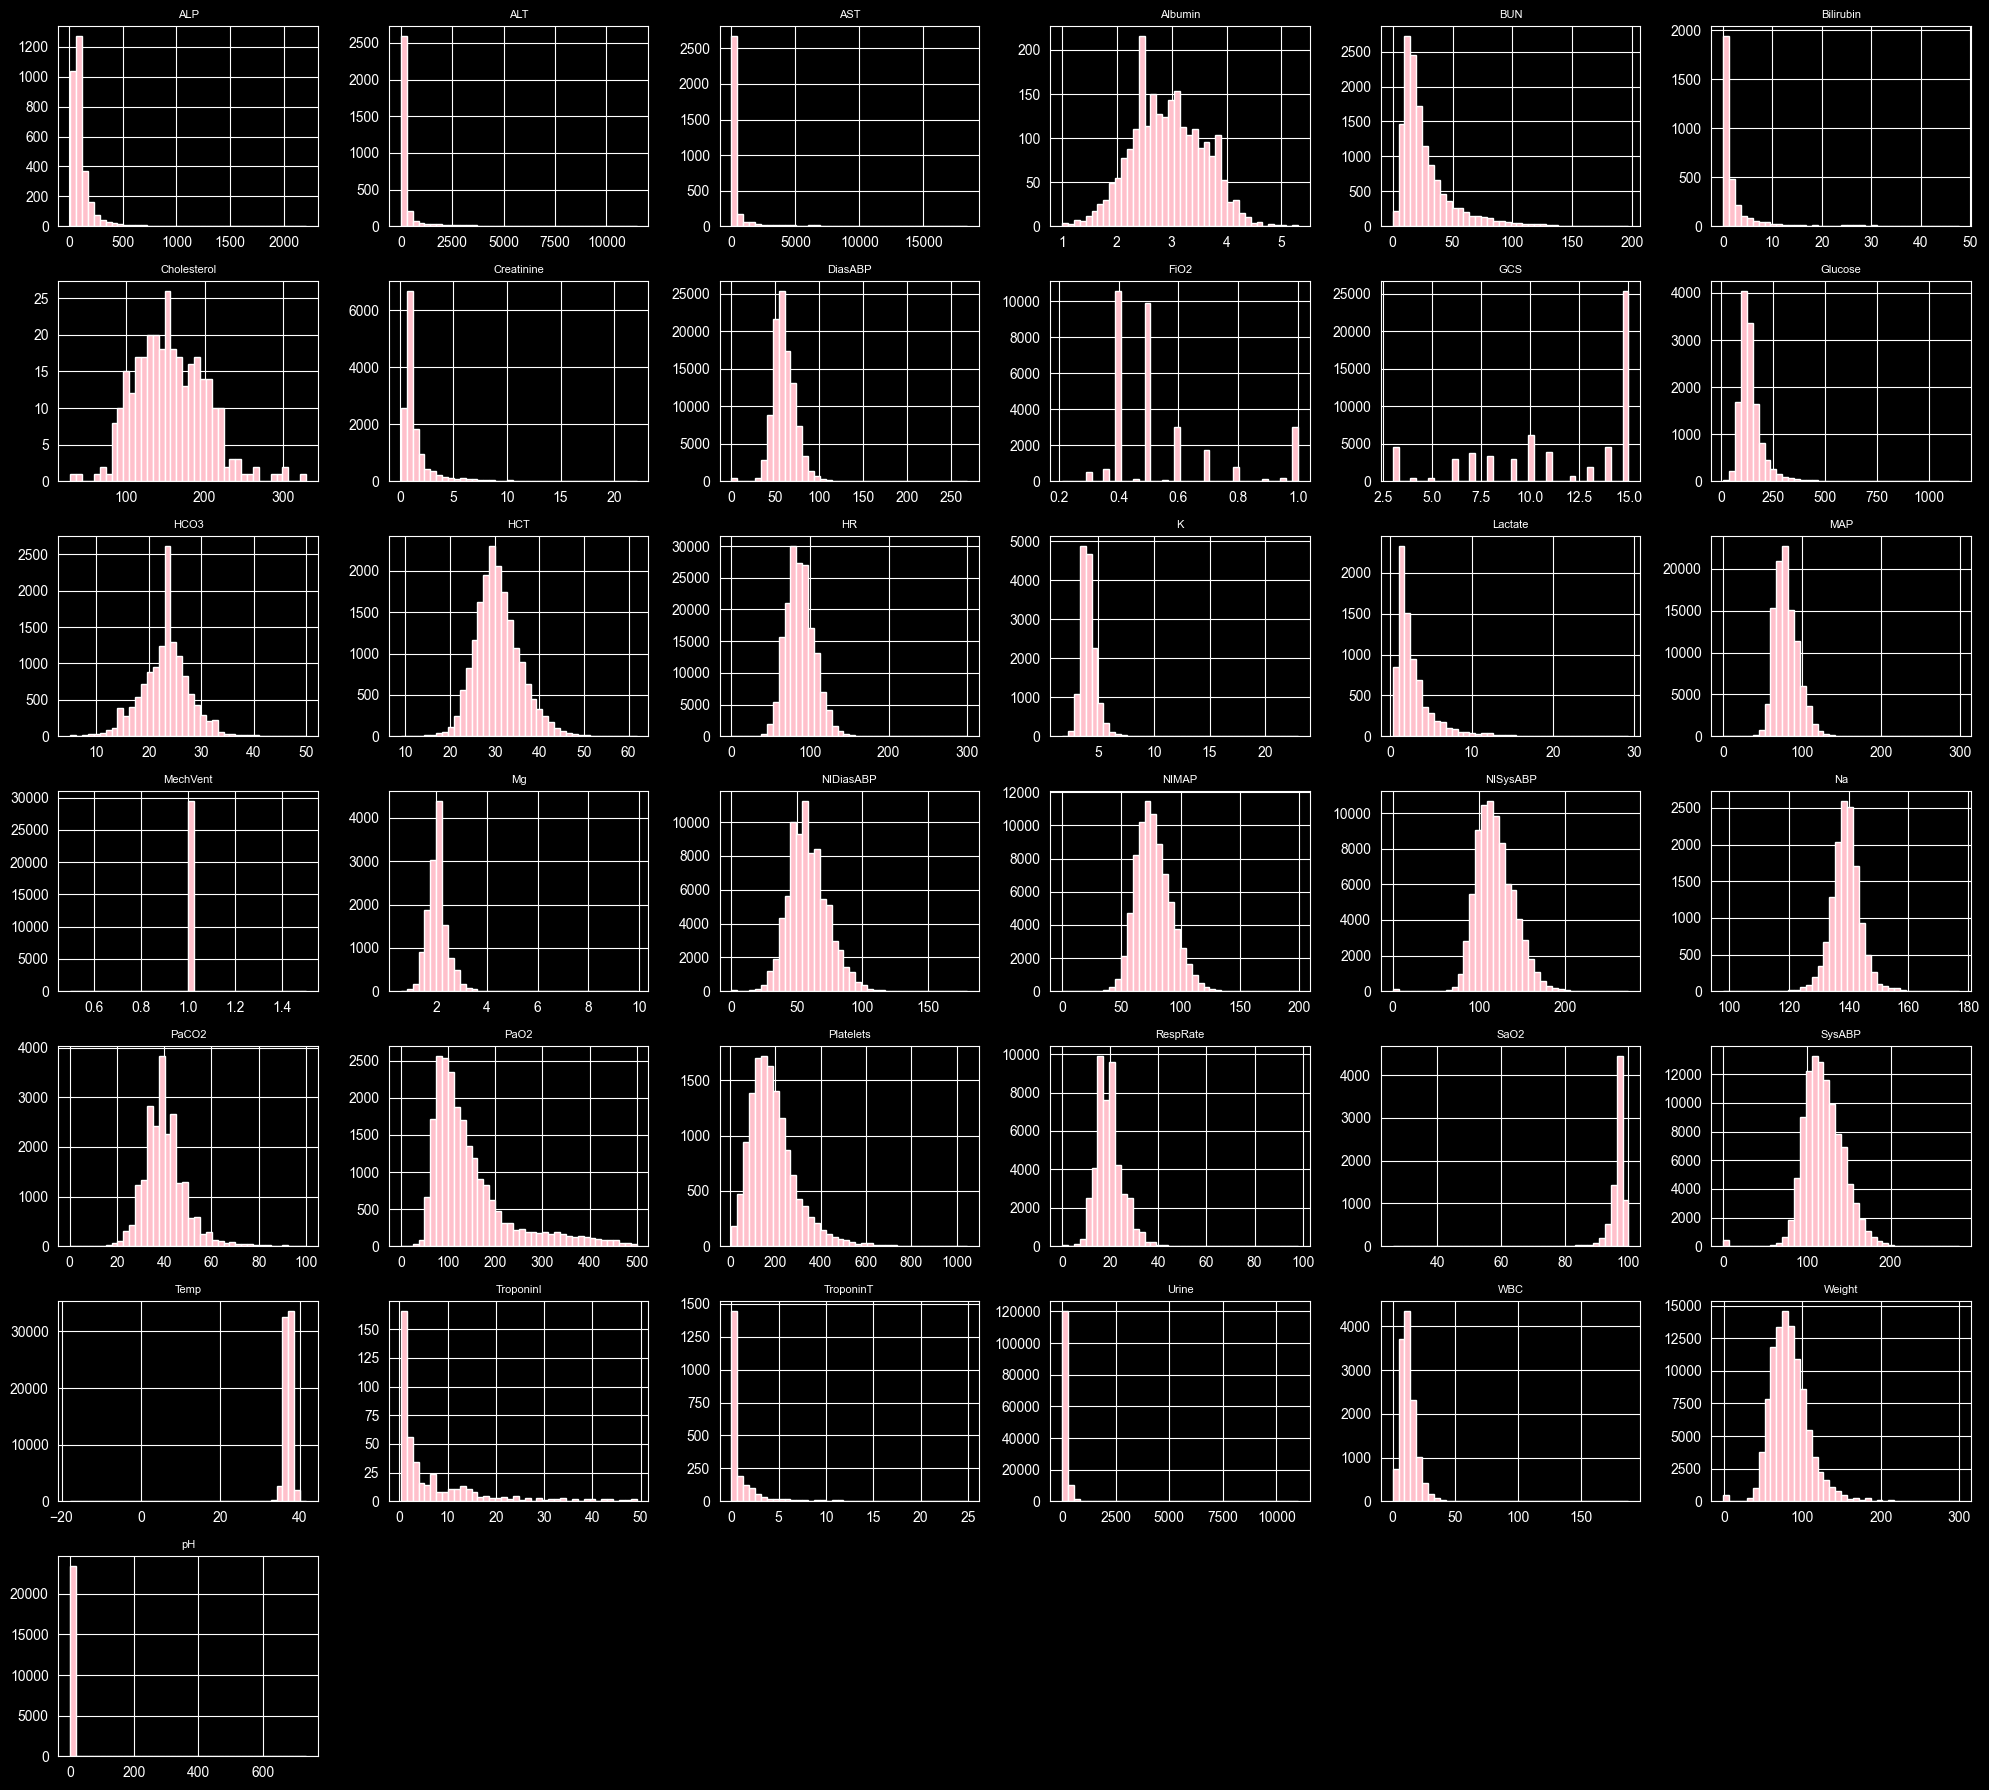

In [26]:
import matplotlib.pyplot as plt

# Plot all 37 dynamic variables in a grid
fig, axes = plt.subplots(7, 6, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(DYNAMIC_VARS):
    axes[i].hist(df_a[col].dropna(), bins=40, color='pink')
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
df_a[df_a["MechVent"] == 0]
# count number of nas in the MechVent column
num_nas_mechvent = df_a["MechVent"].isna().sum()
print(f"Number of NaN values in 'MechVent' column: {num_nas_mechvent}")
#number of values in total
total_values_mechvent = df_a["MechVent"].shape[0]
print(f"Total number of values in 'MechVent' column: {total_values_mechvent}")

Number of NaN values in 'MechVent' column: 166520
Total number of values in 'MechVent' column: 196000


## Interesting observations:
### First observation:
The MechVent (Mechanical ventilation respiration) has only values of 1 (true), which means they did not put any value when they MechVent was false (0), so we know for imputation we have to put 0 instead of NaN.

### Second observation:
For the pH-value, we observed three values of 700. and five values of 100. The allowed scale is from 0 to 14, the other patients have values between 6.86 to 7.66. We will remove the values around 100, because we do not know what they should be, but the values of 700., we will devide by 100 as the comma was set wrong. There is also one value of 1 and one value of 3, which we noted ad suspicious.





## Age filtering
We filter the age in 10 year bins to spot the differences. There are no patients younger than 10 and older than 100.

In [28]:

def add_age_bin(df, bins=range(10, 101, 10)):
    df = df.copy()
    df["age_bin"] = pd.cut(
        df["Age"],
        bins=bins,
        right=False,
        include_lowest=True
    )
    return df

                  ALP          ALT          AST   Albumin        BUN  \
age_bin                                                                
[10, 20)   114.781250  1225.000000   867.606061  3.095652  12.384615   
[20, 30)    79.500000  1629.077778  1364.888889  3.140351  16.440120   
[30, 40)   118.909605   970.132597   900.116667  2.938462  19.224436   
[40, 50)   121.547253   352.229958   538.816842  2.887000  22.715561   
[50, 60)   120.564924   273.556837   481.741408  2.986792  27.099534   
[60, 70)   114.875926   361.991023   588.541367  2.868075  27.805807   
[70, 80)   109.508972   220.809984   312.323151  2.899366  29.715938   
[80, 90)   115.375610   153.218750   211.448441  2.898656  31.799486   
[90, 100)  194.030612    73.000000    91.852941  2.871429  36.275416   

           Bilirubin  Cholesterol  Creatinine    DiasABP      FiO2  ...  \
age_bin                                                             ...   
[10, 20)    2.743333          NaN    1.126724  66.802581 

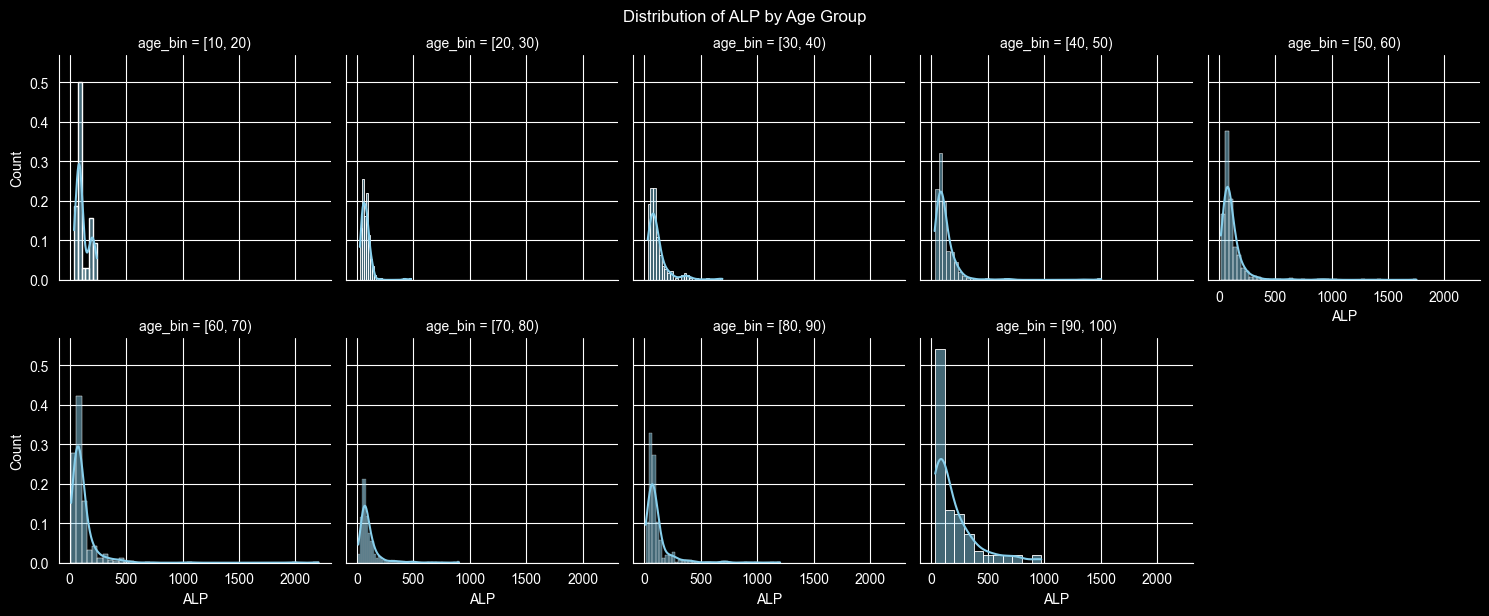

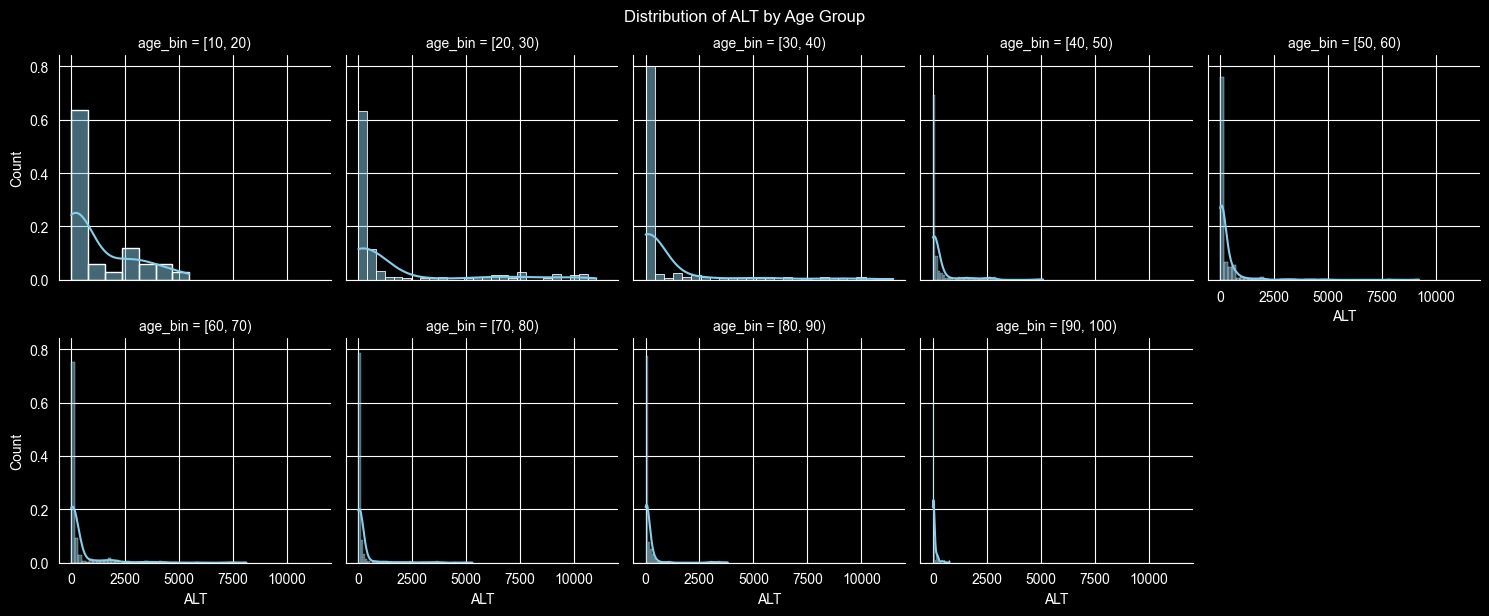

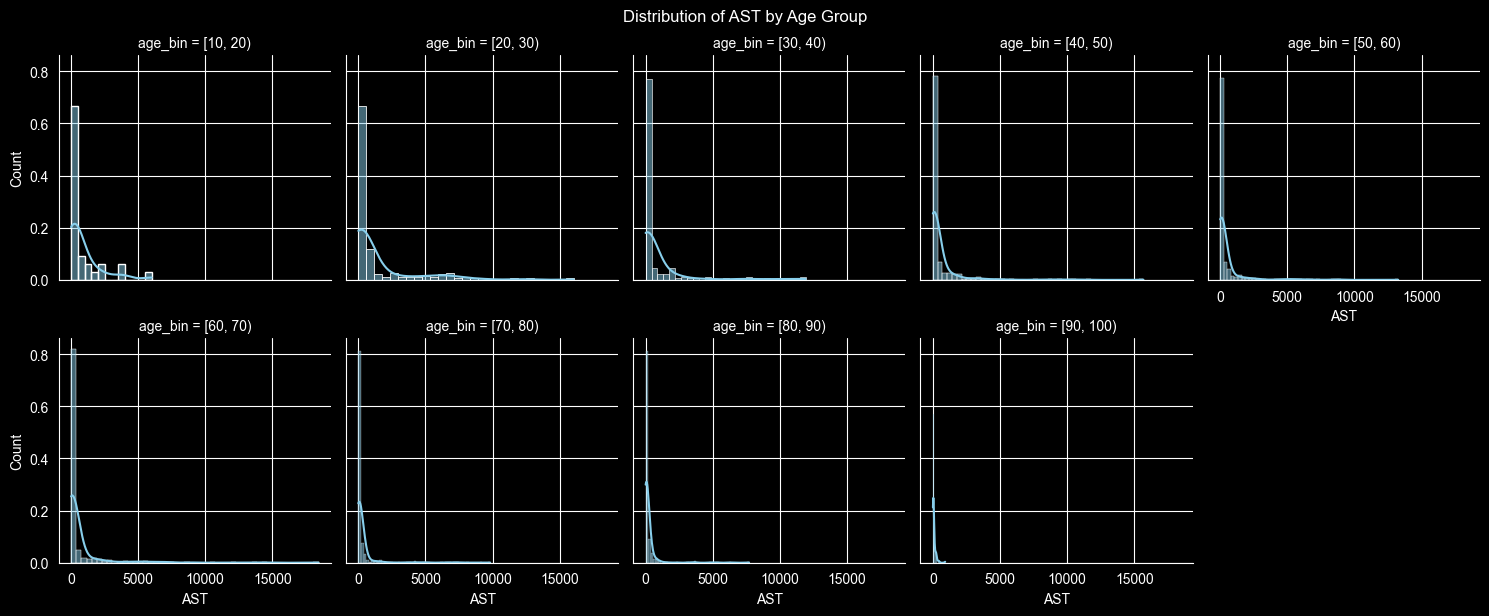

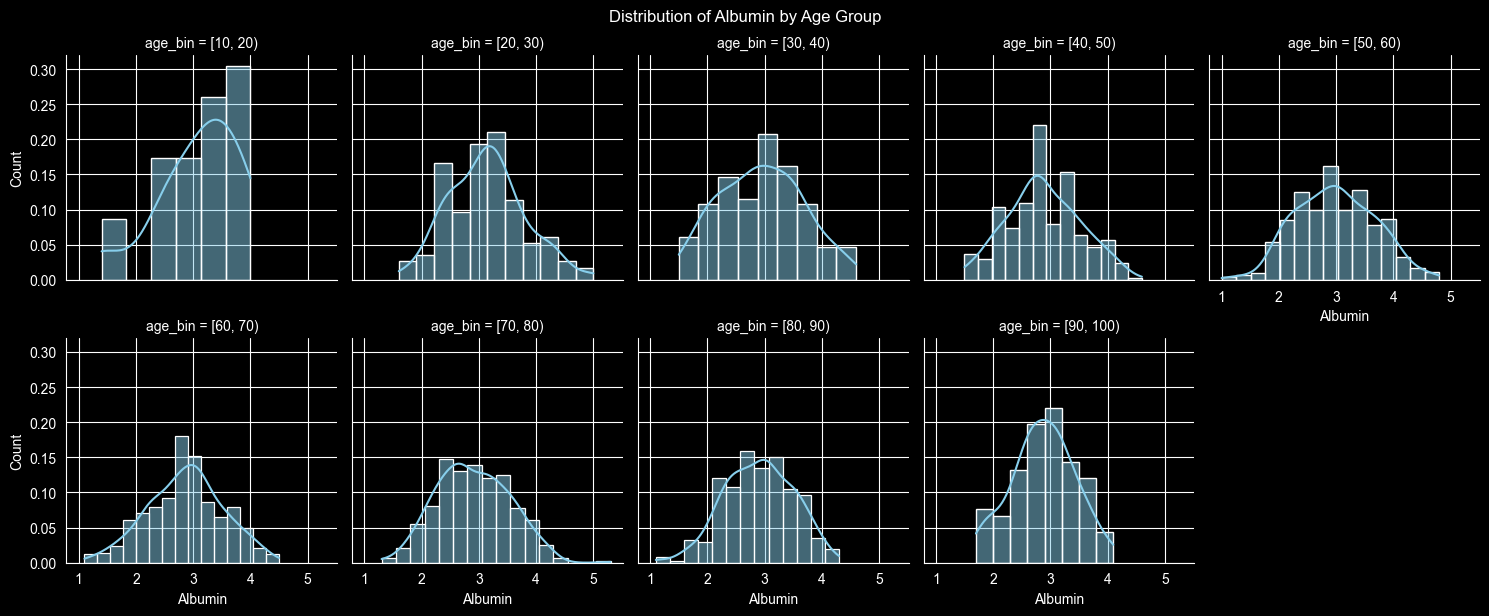

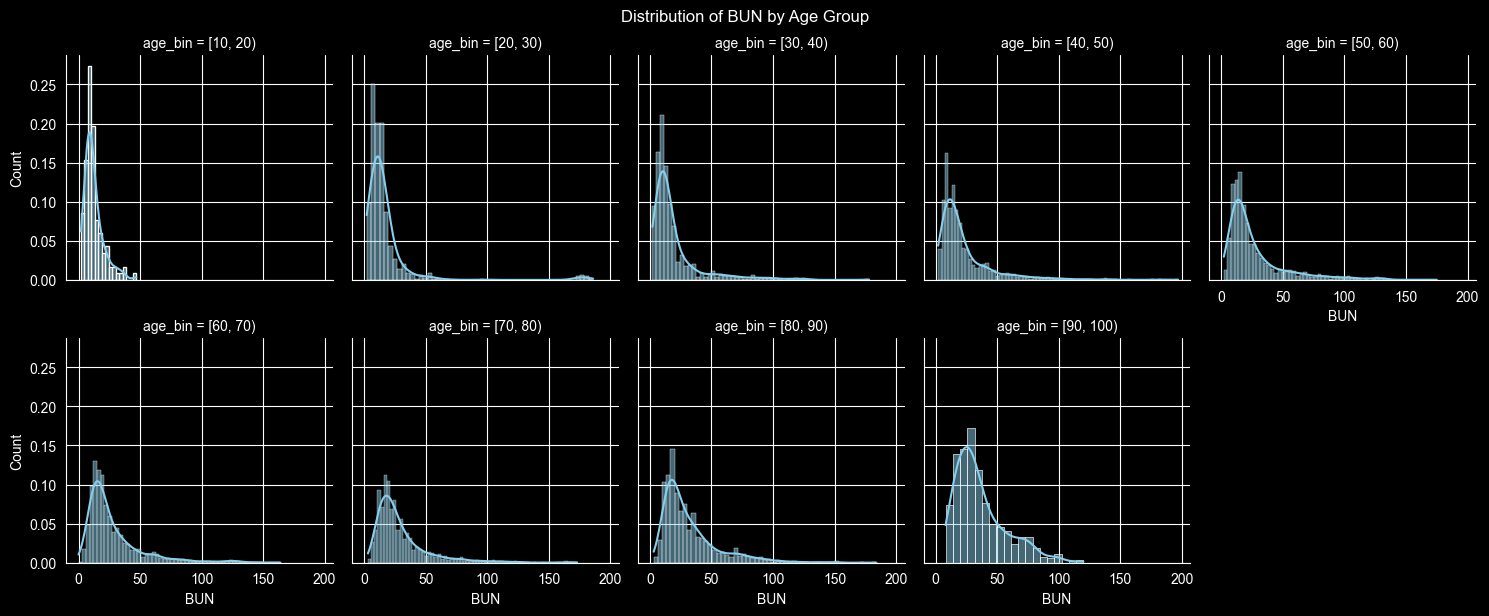

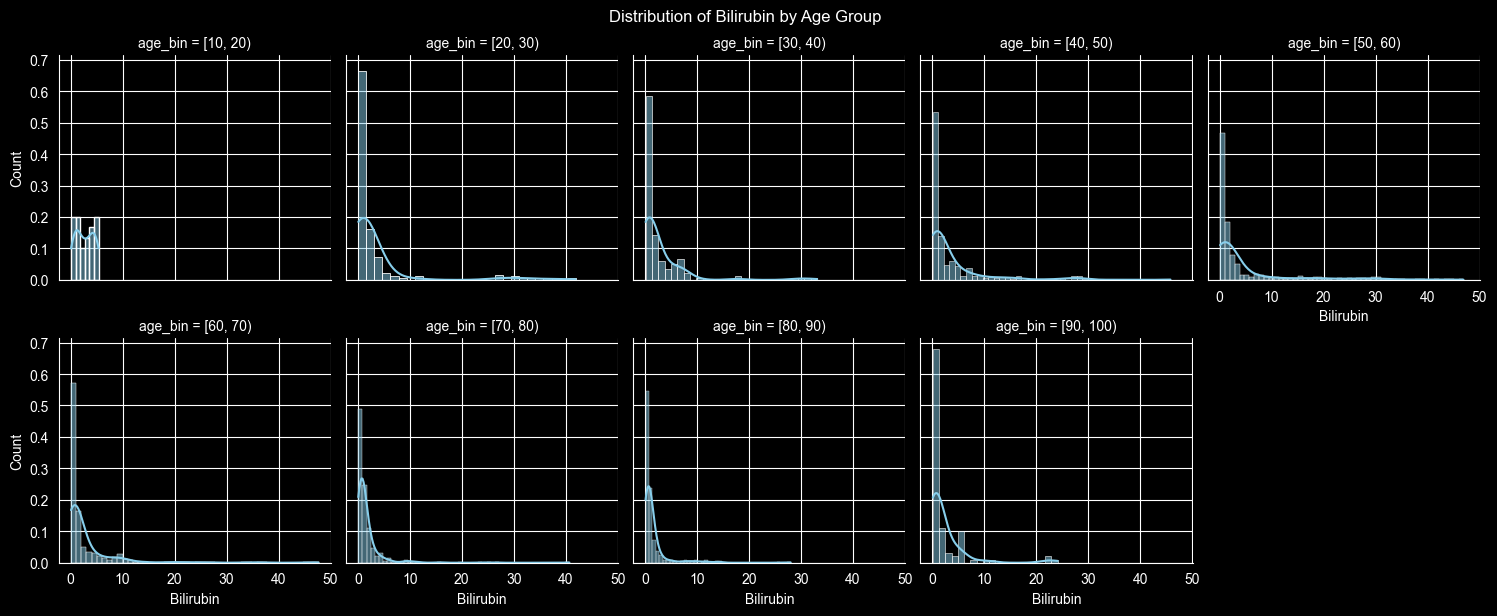

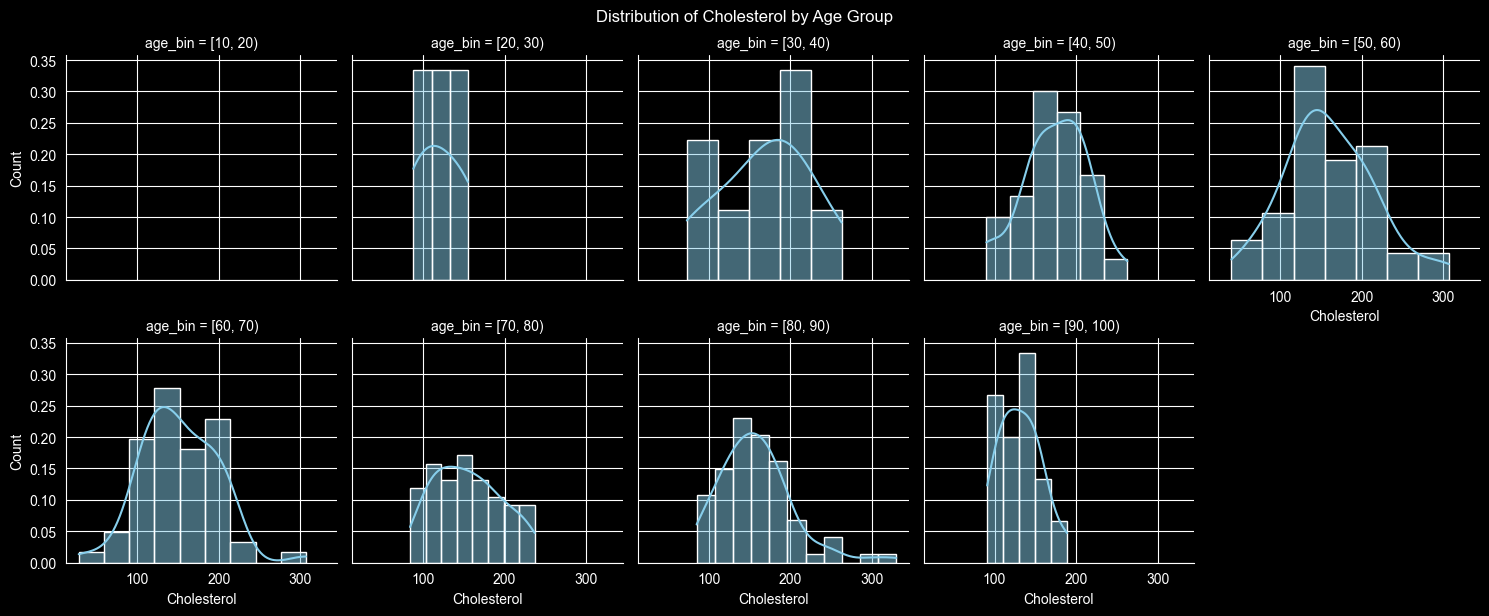

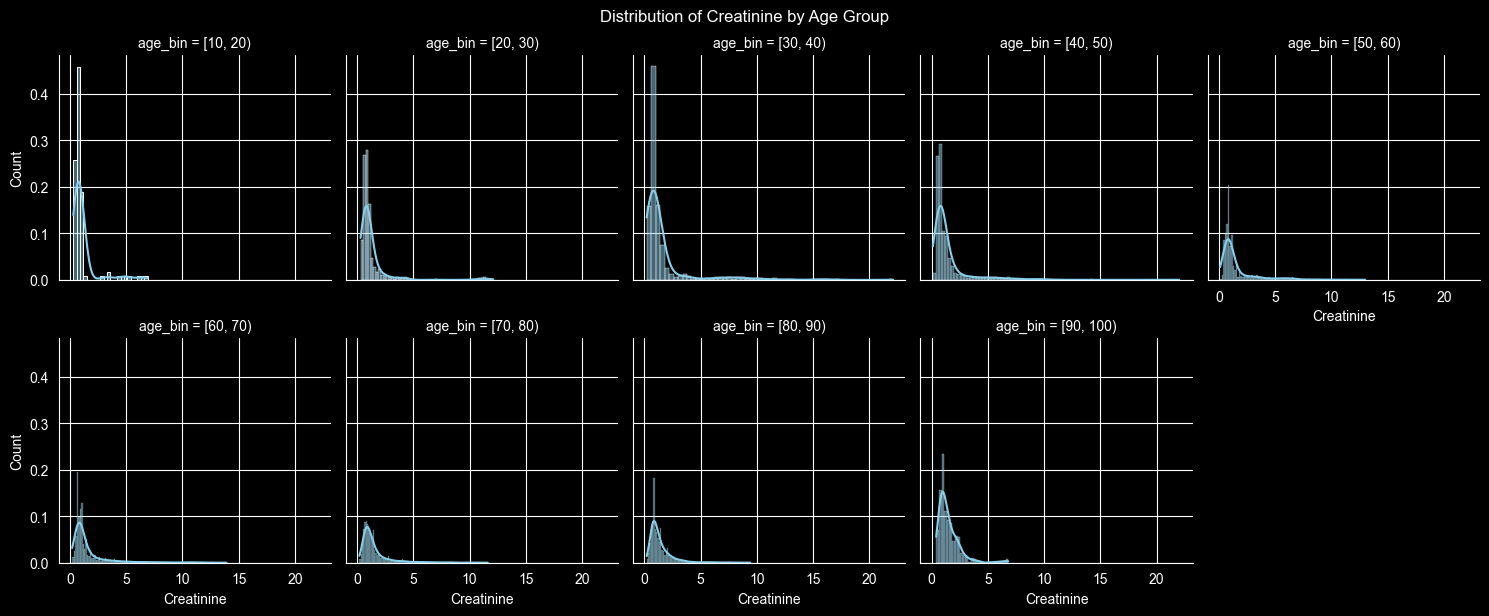

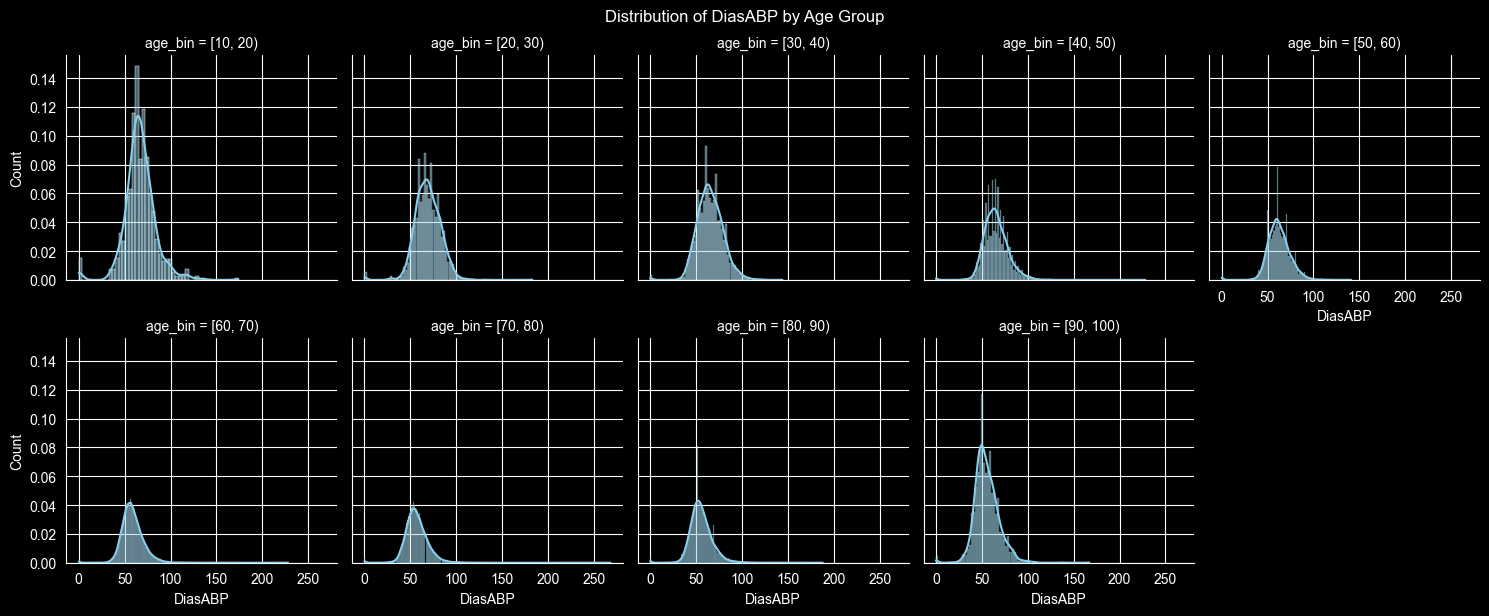

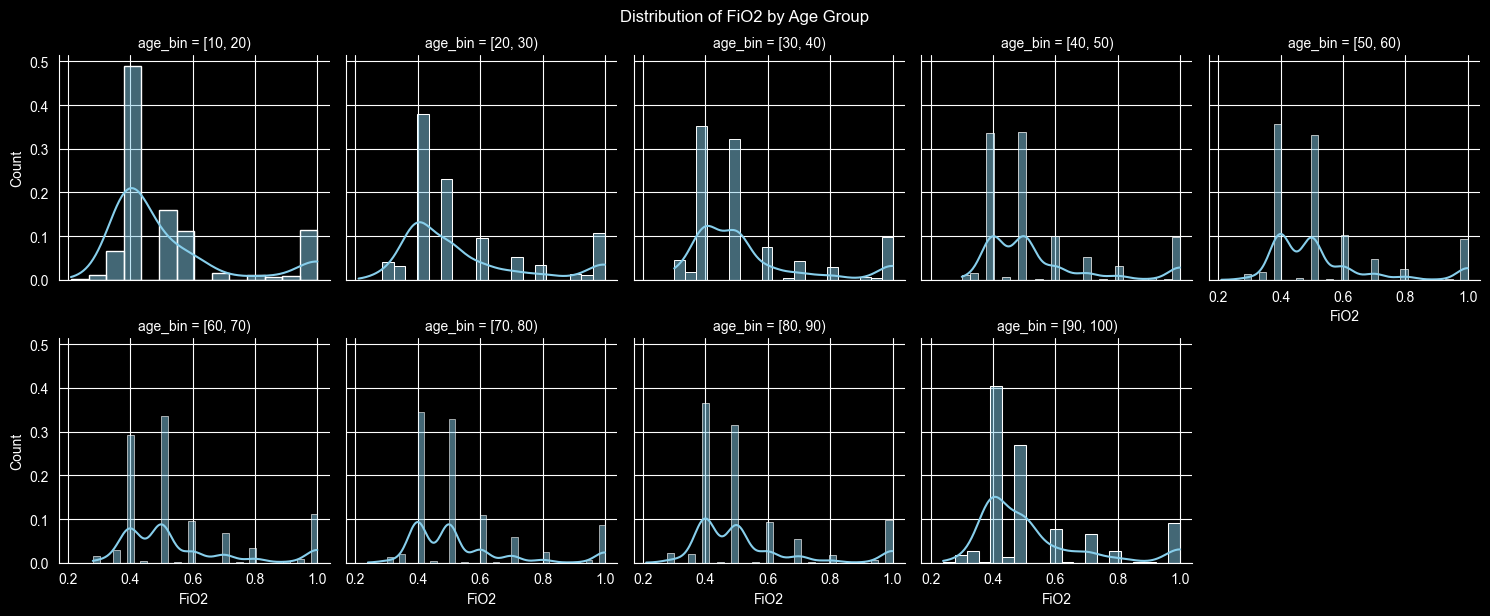

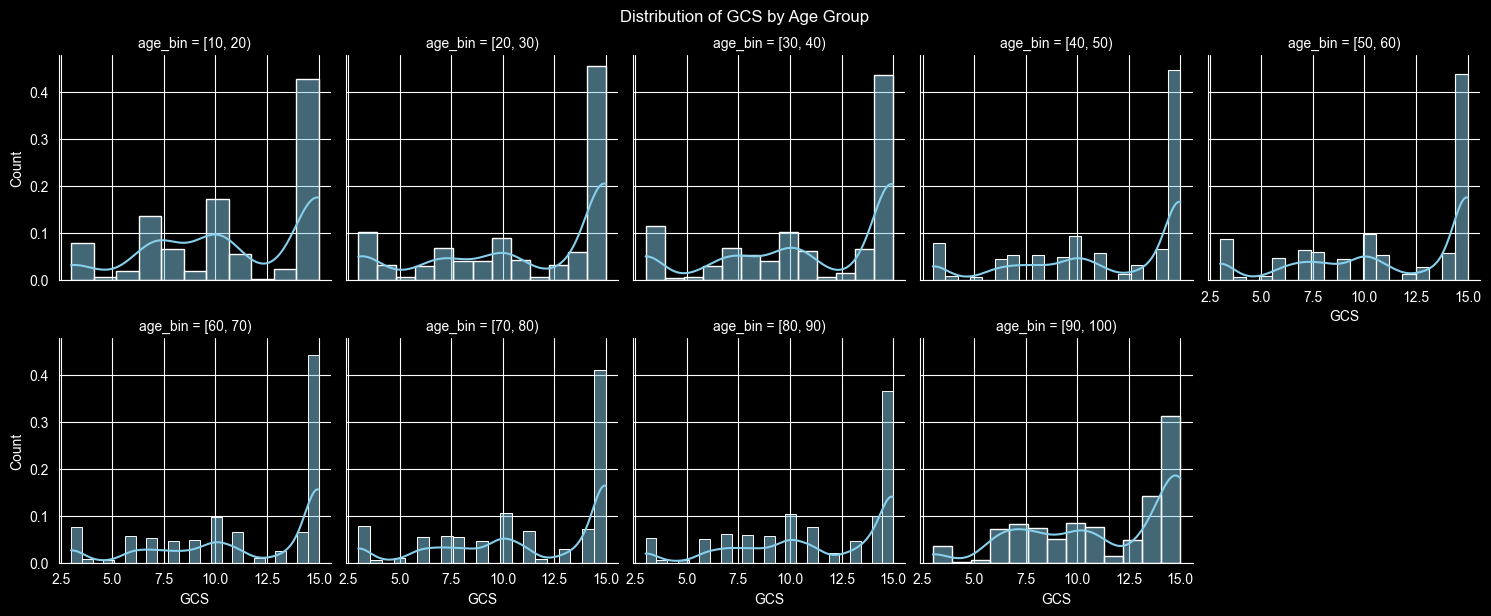

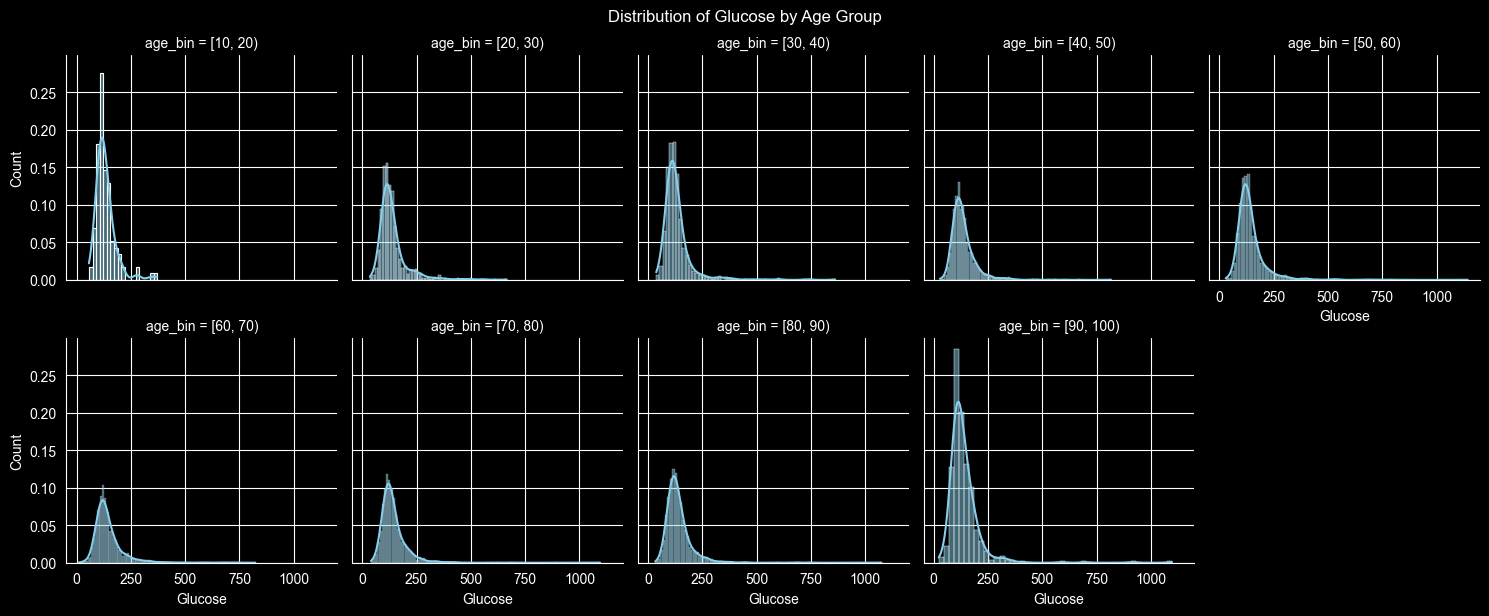

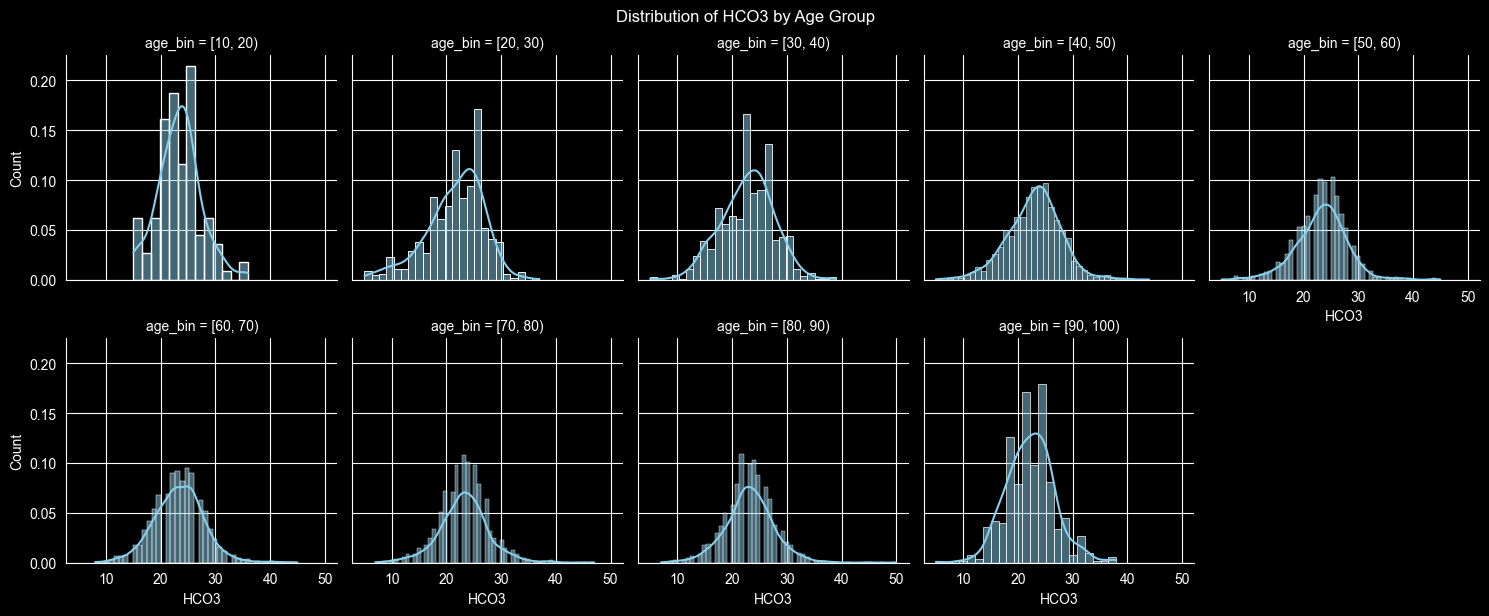

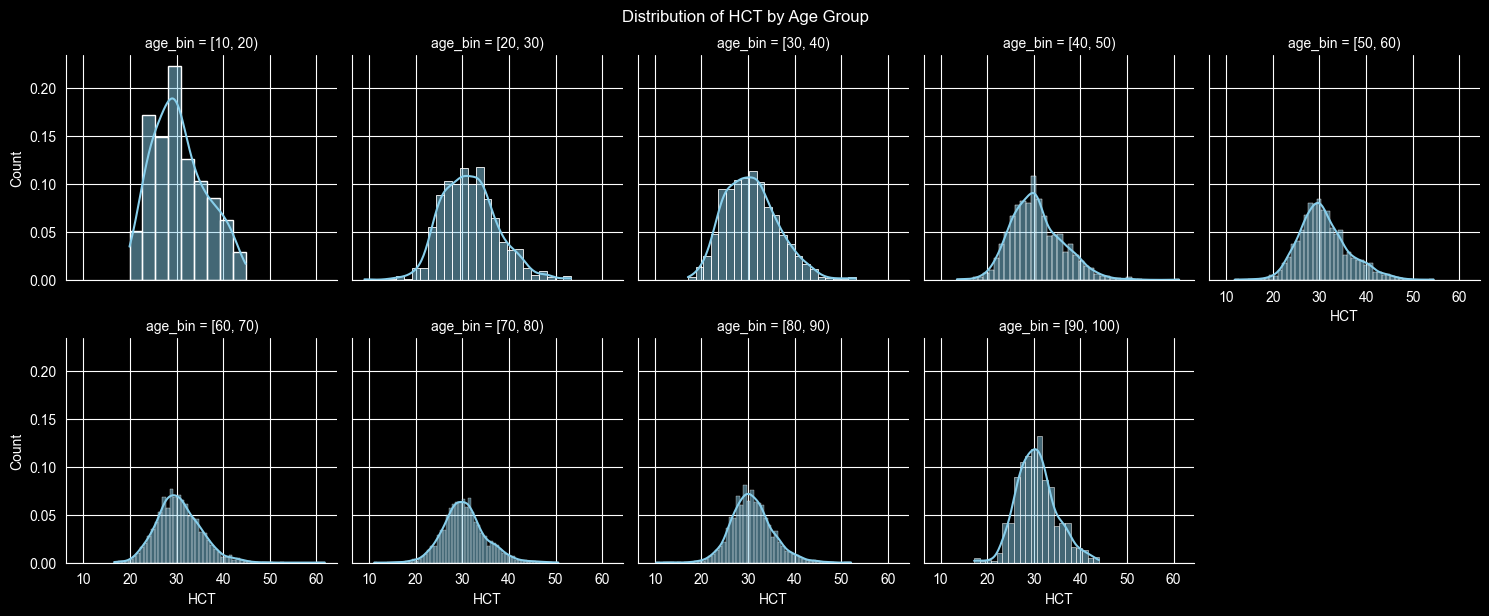

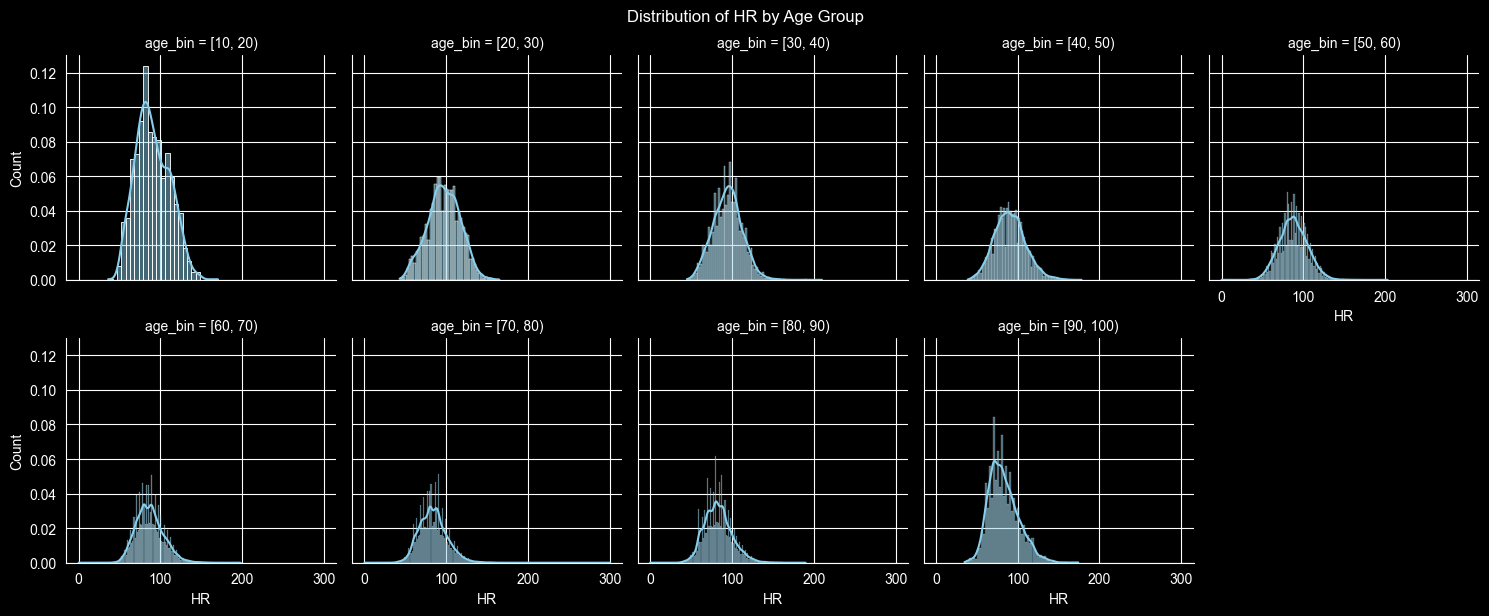

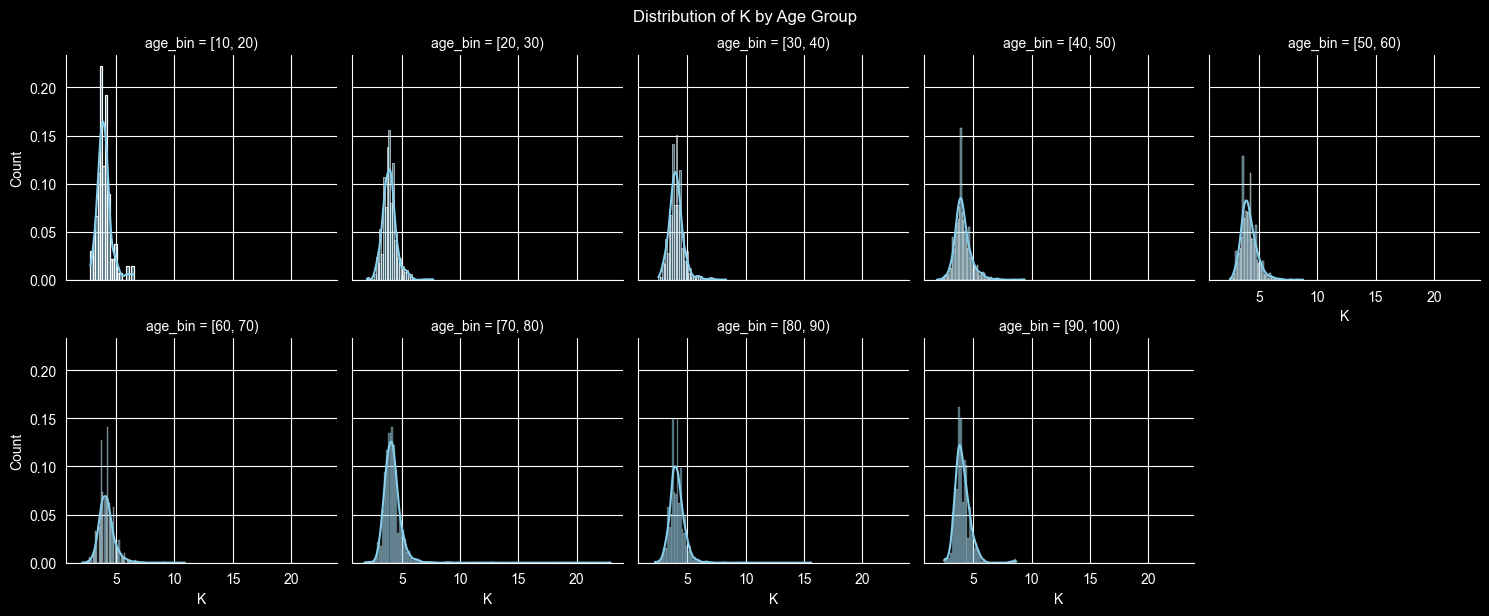

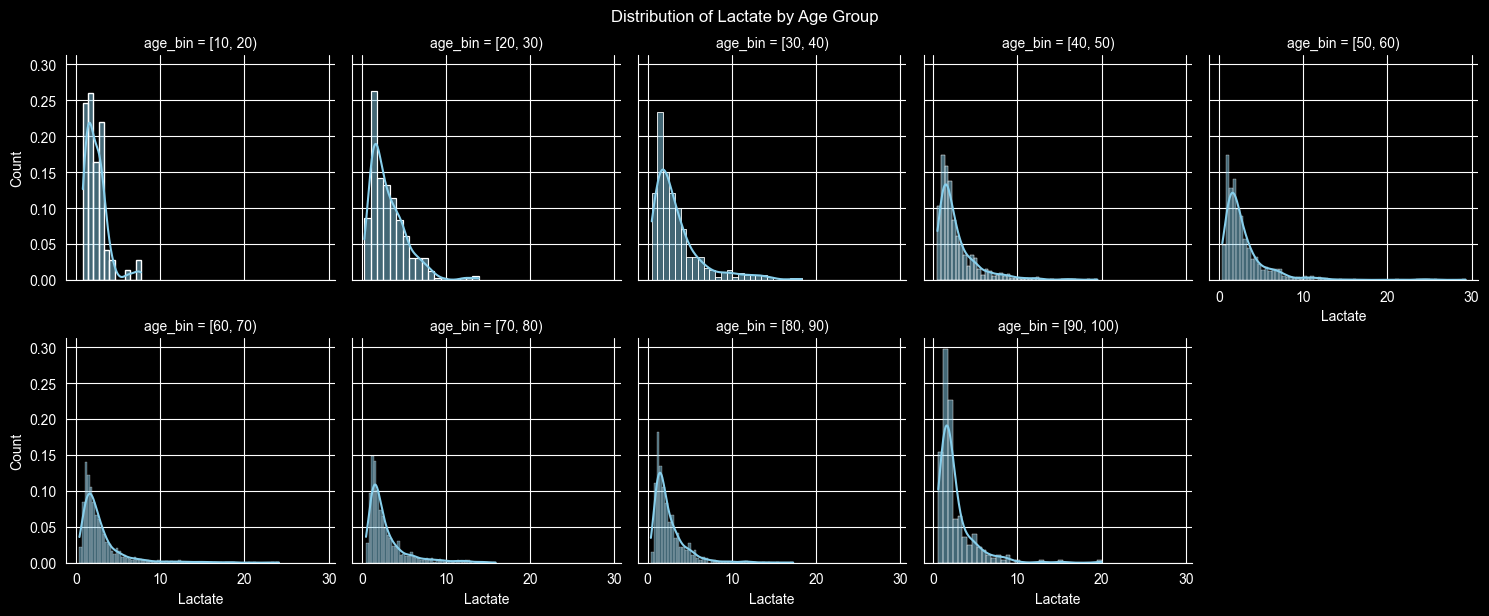

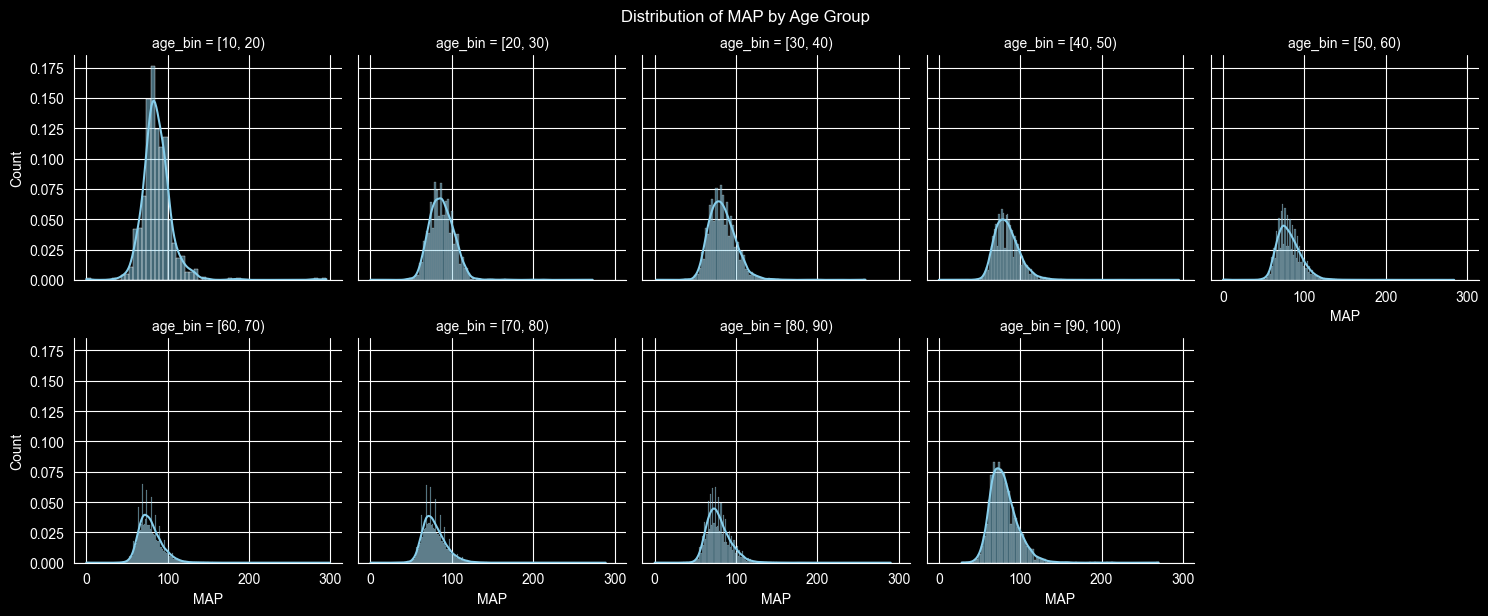

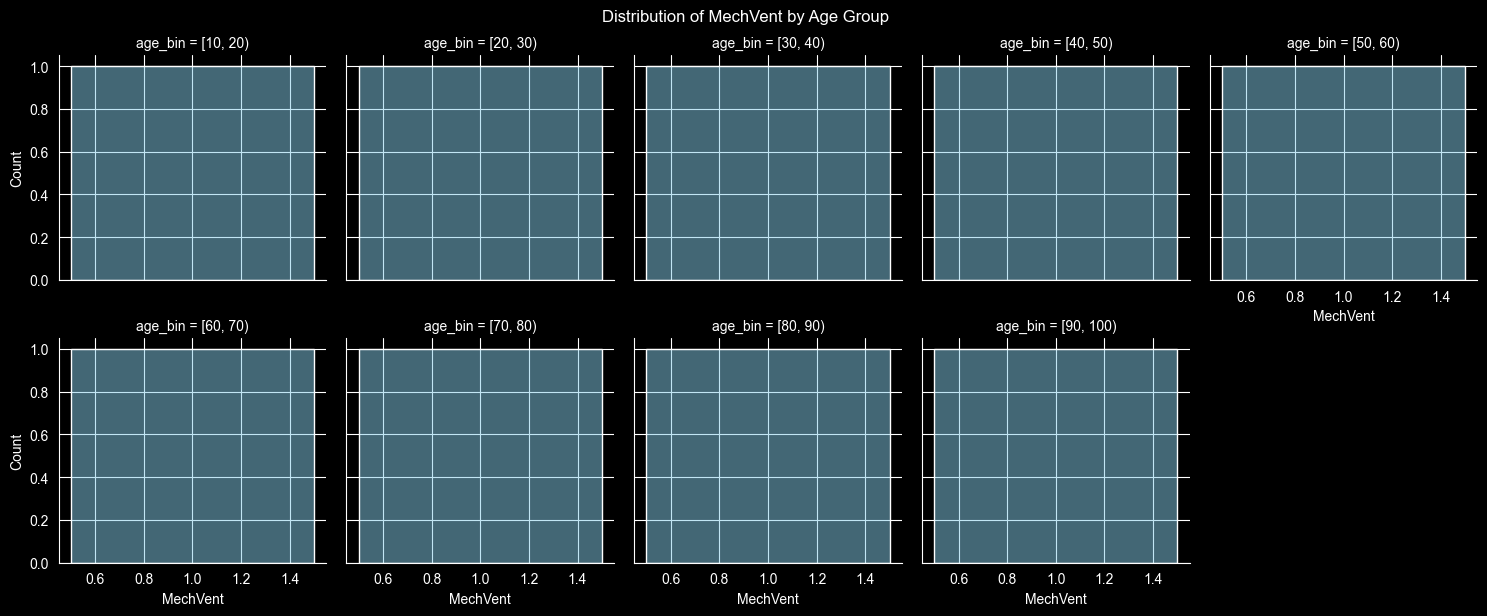

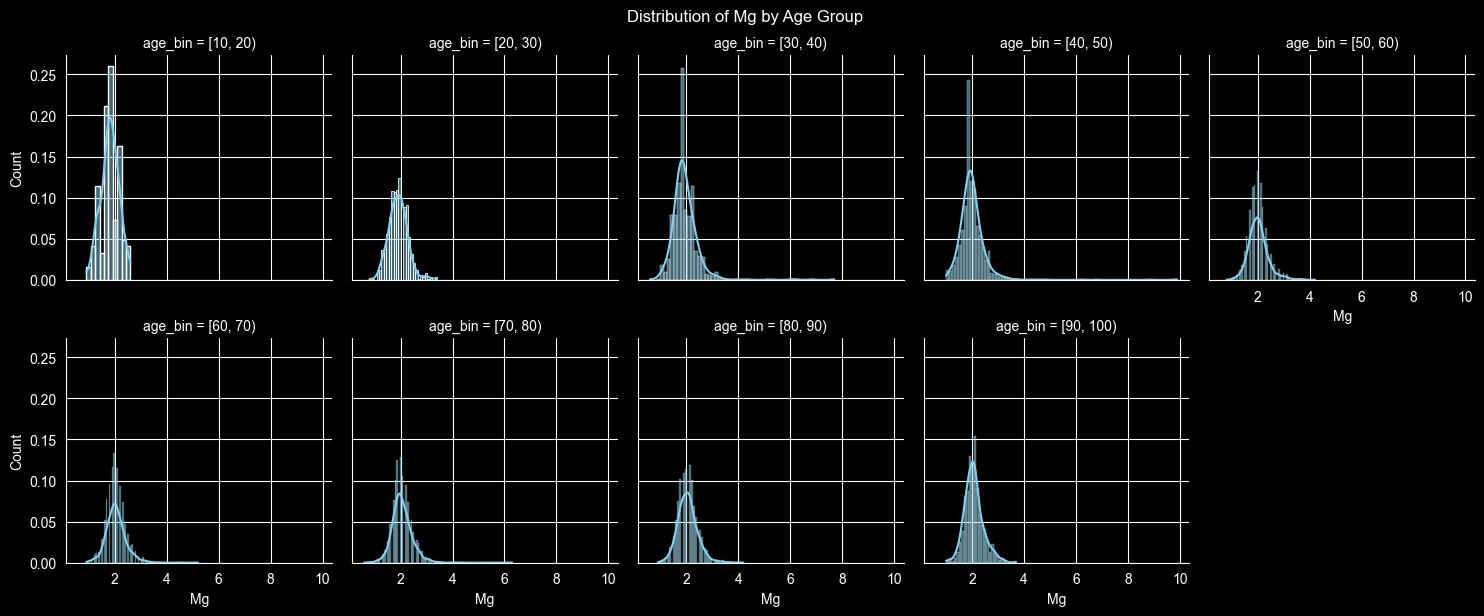

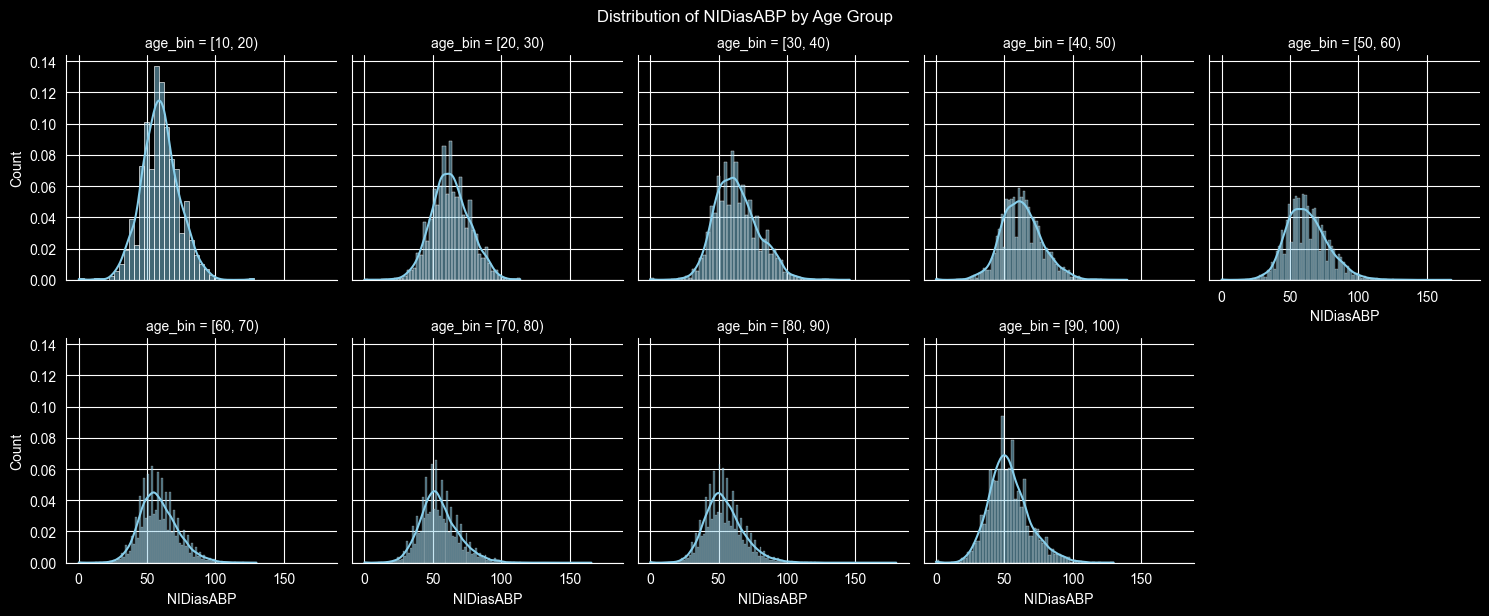

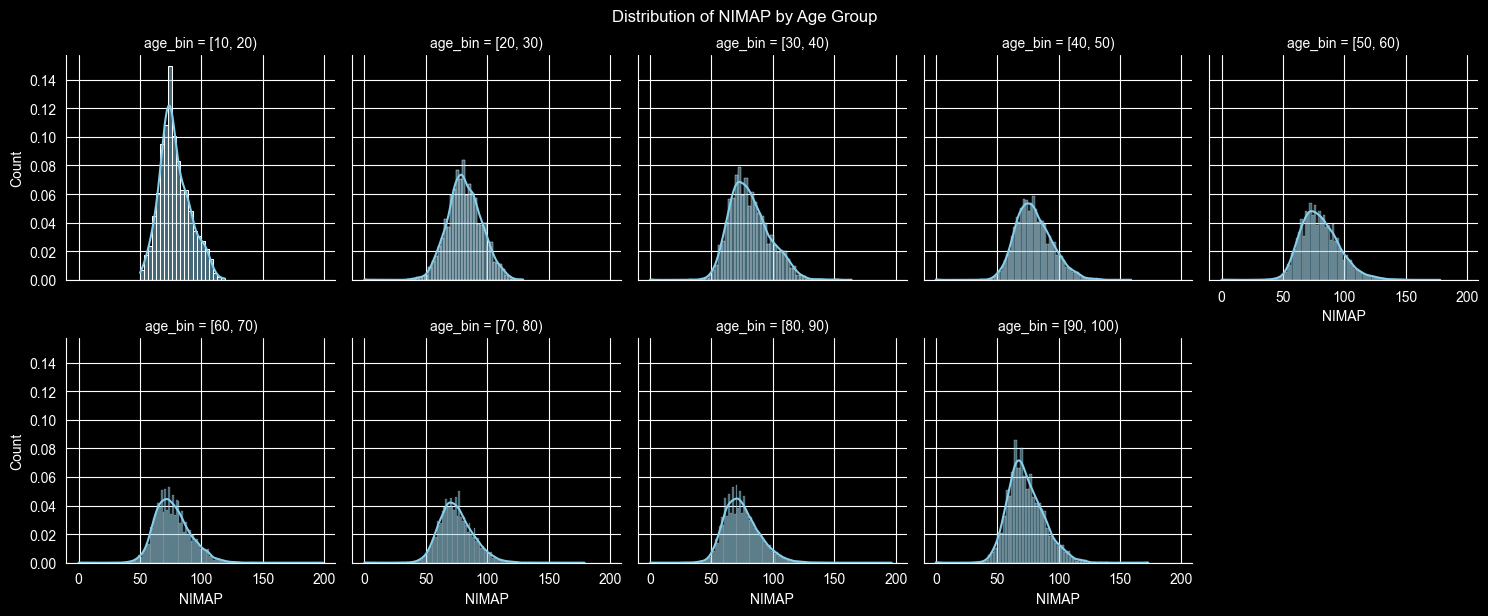

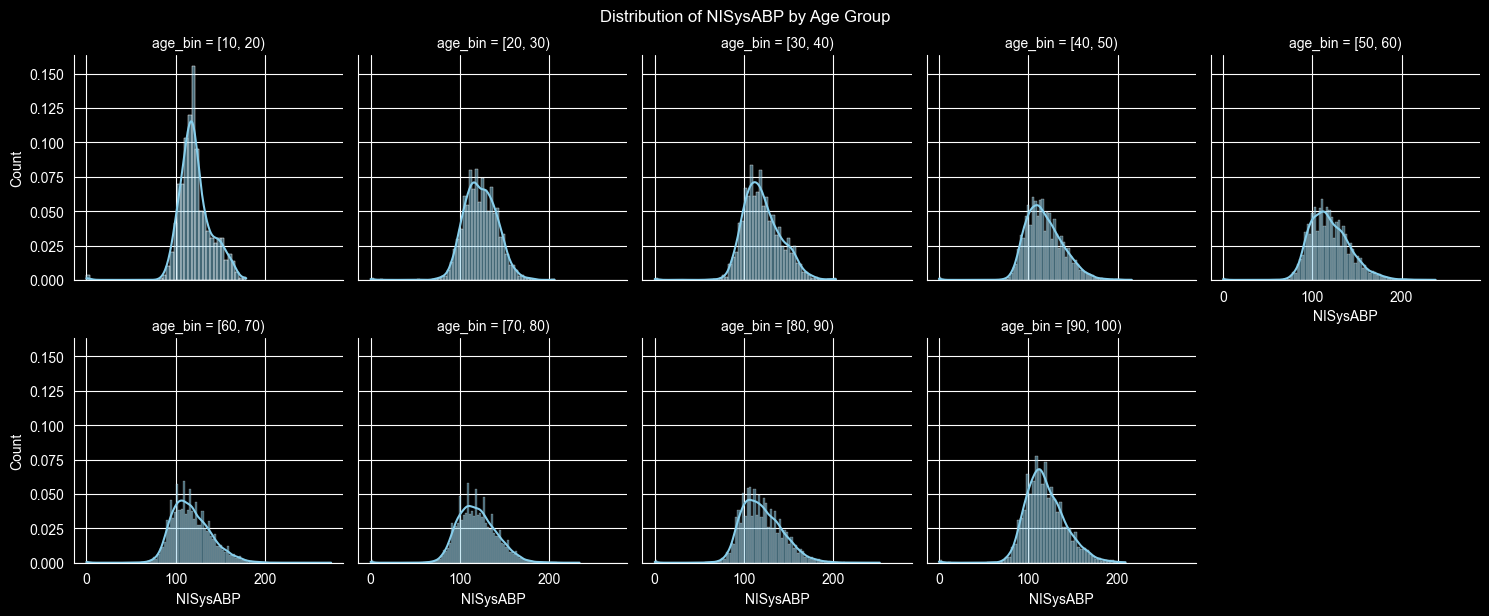

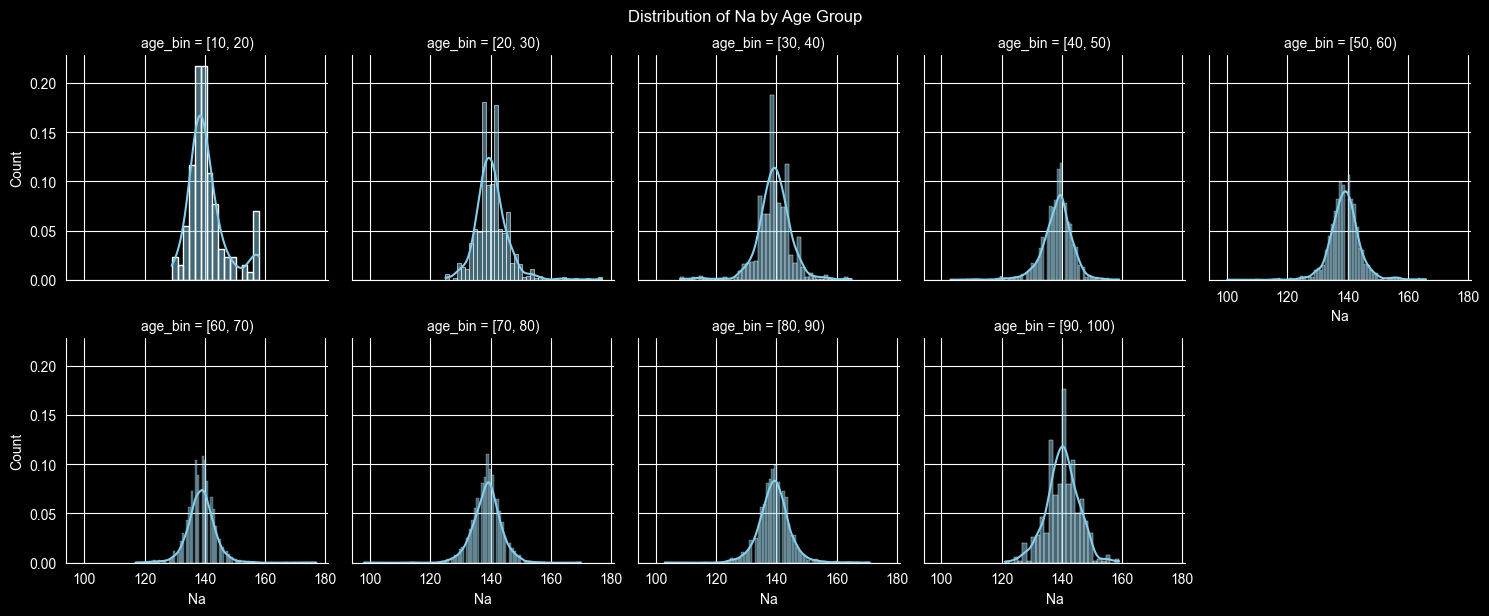

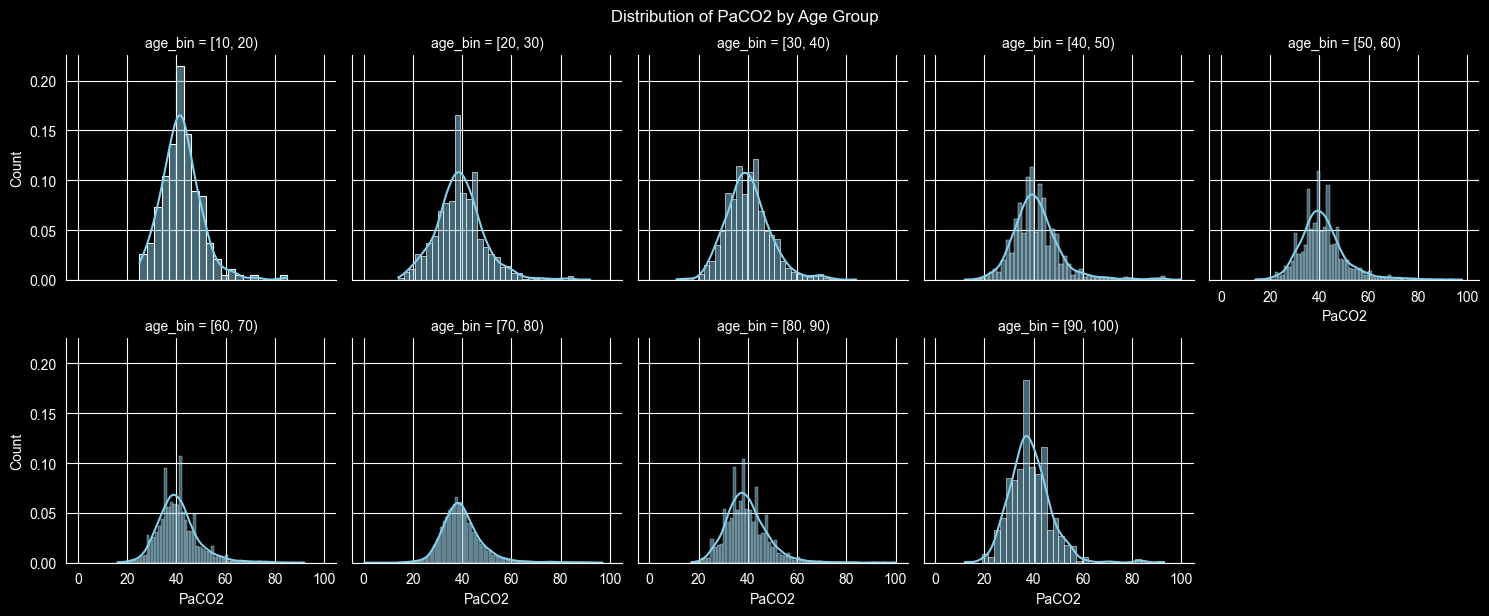

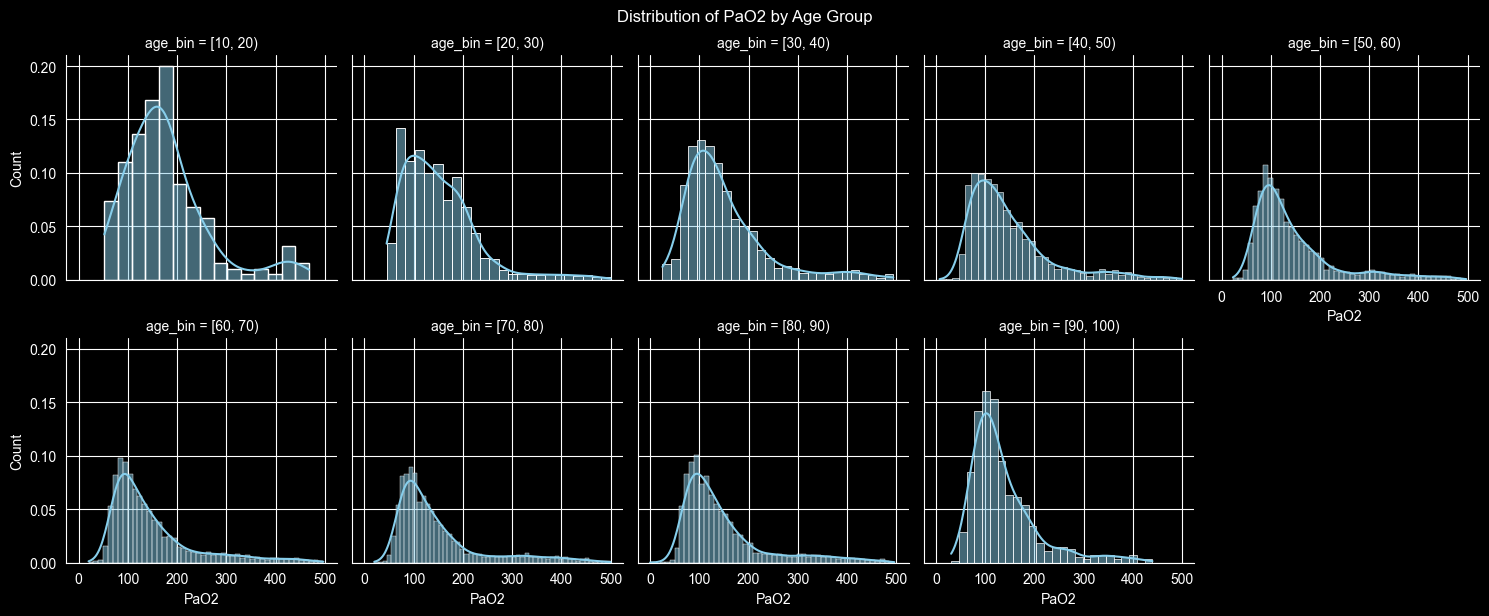

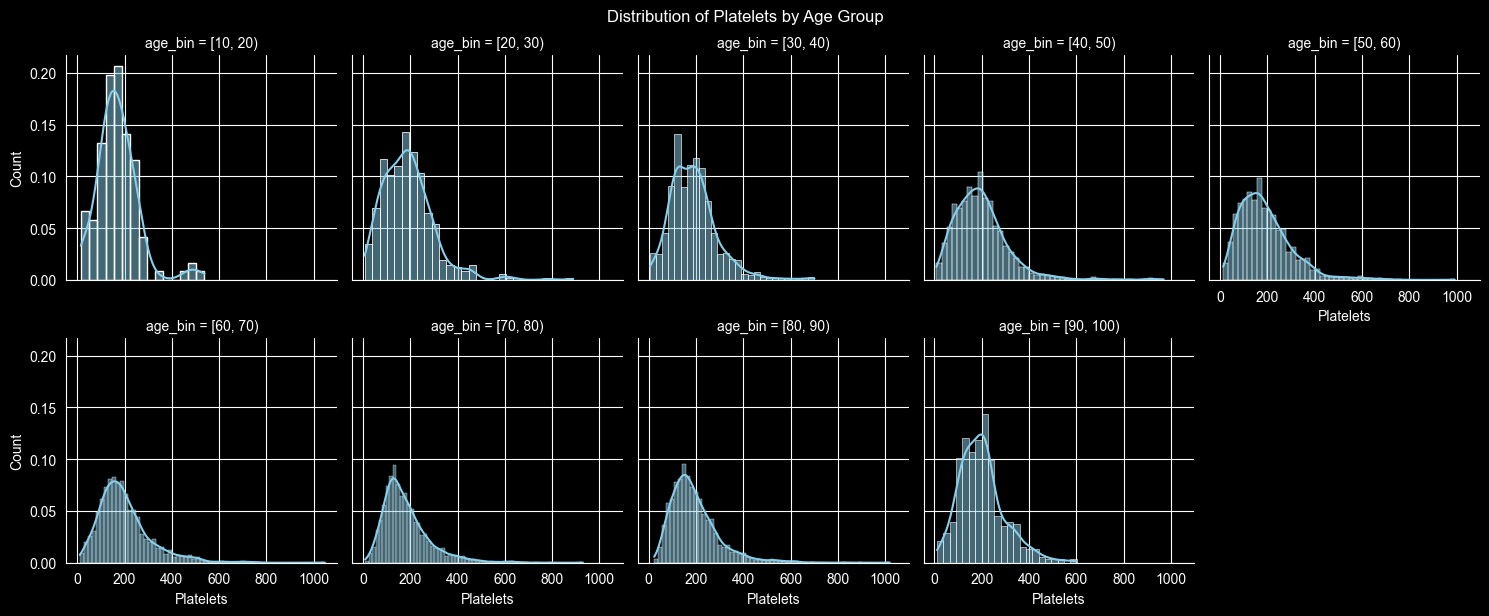

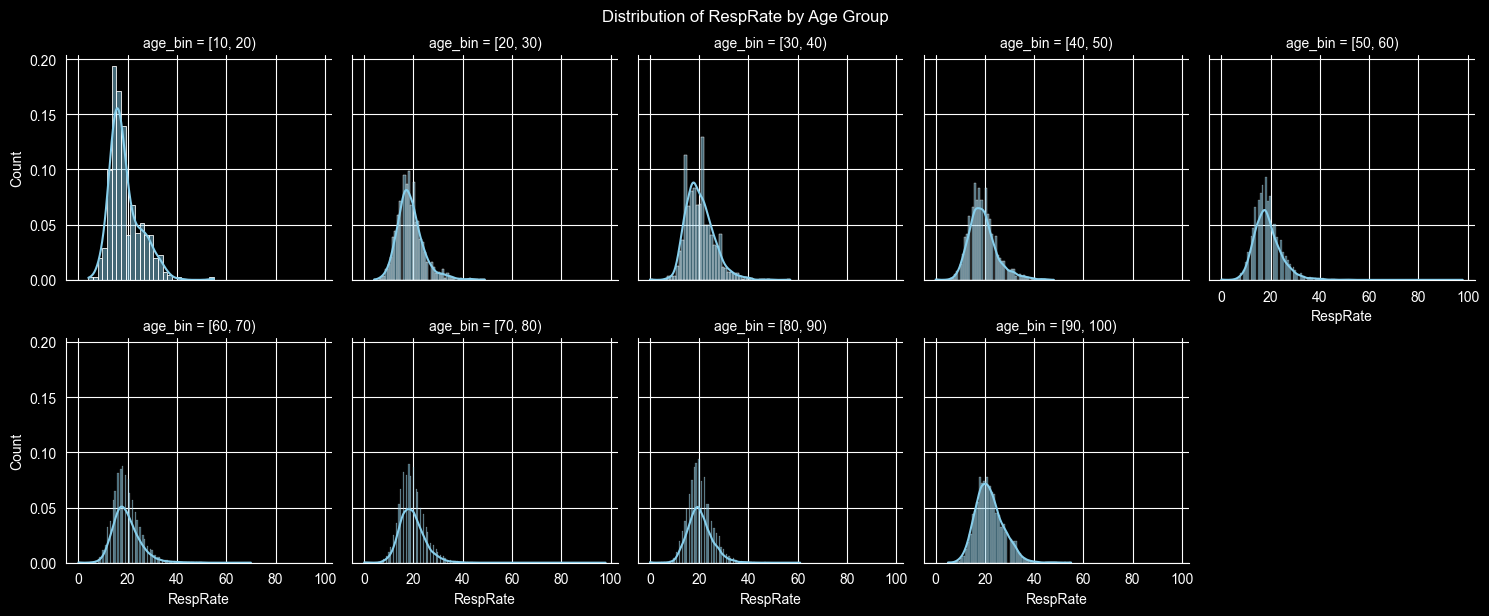

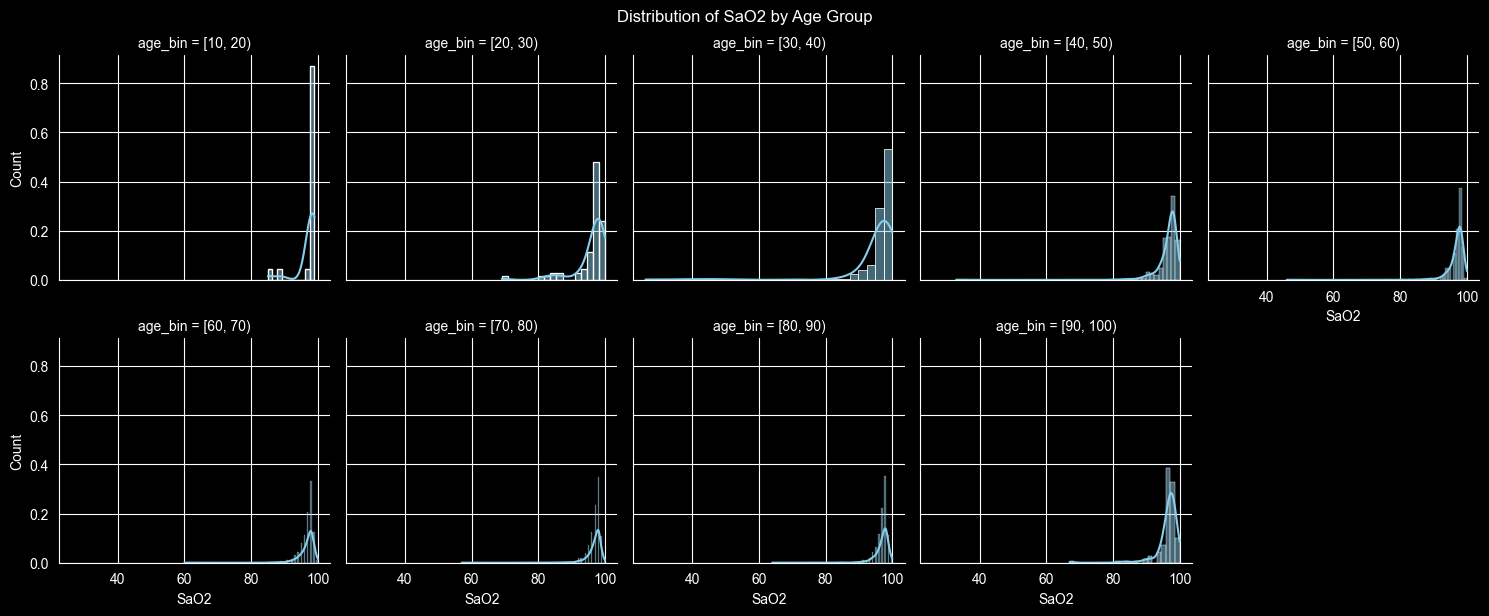

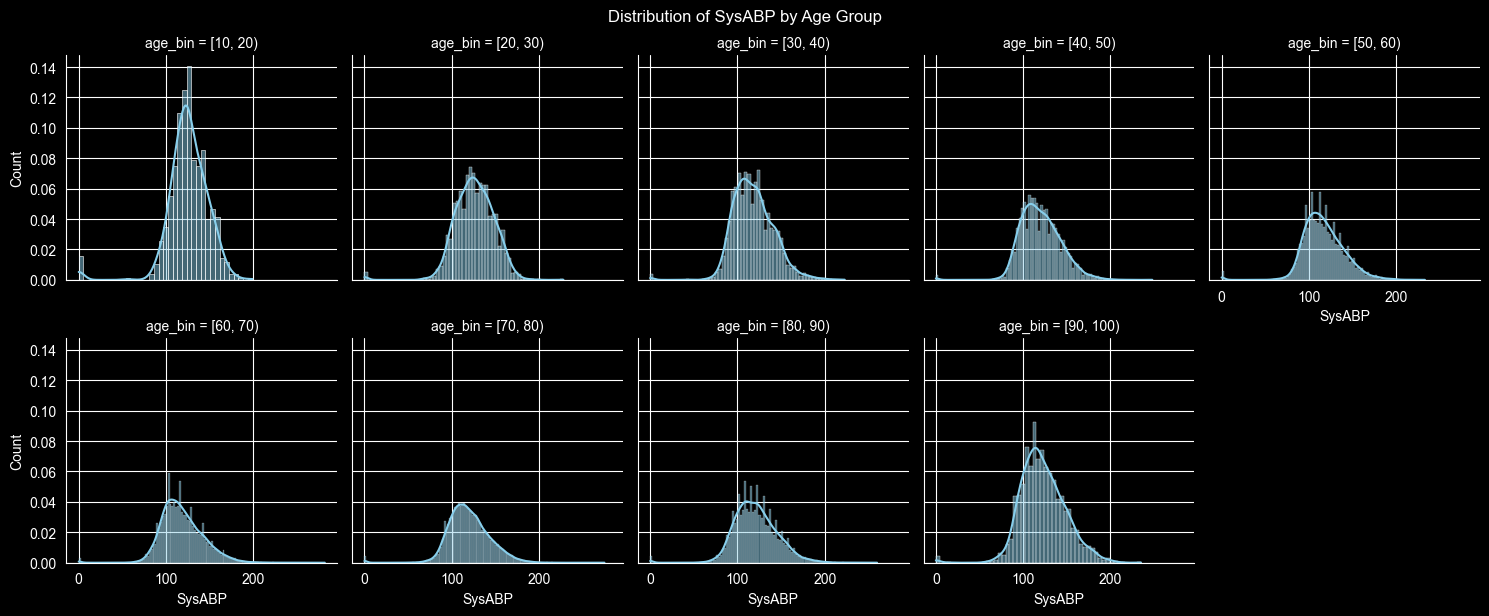

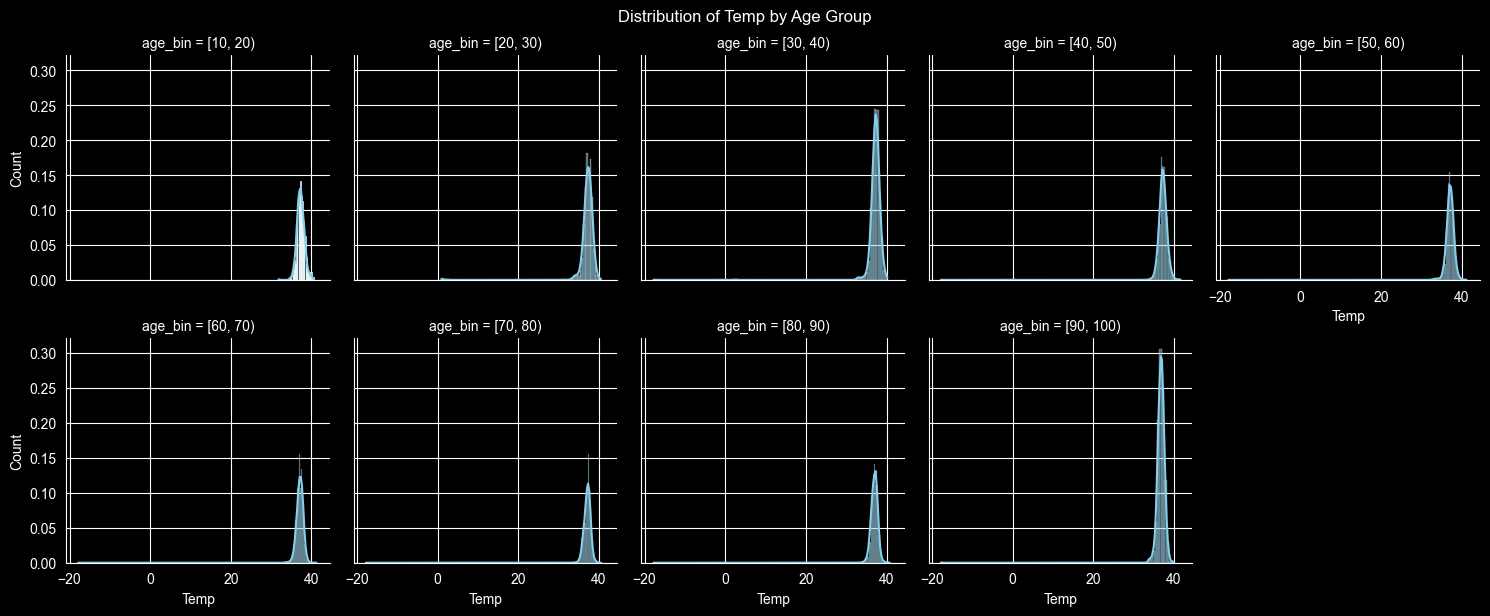

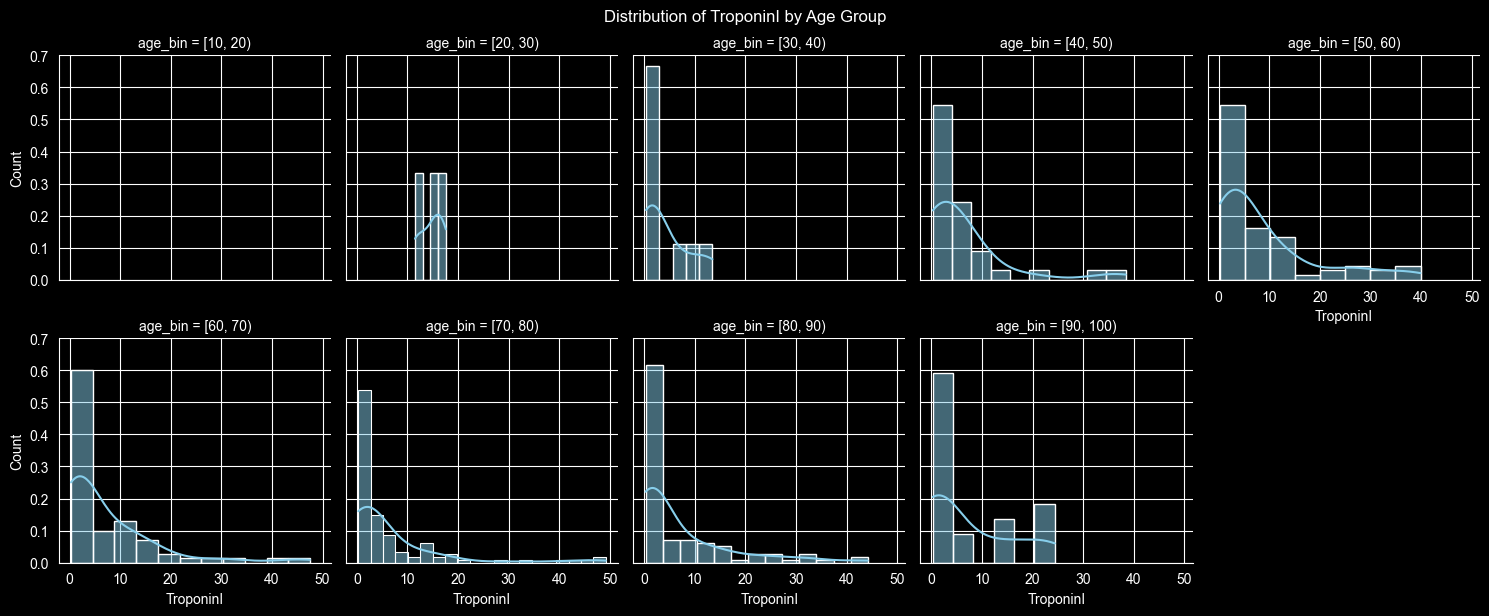

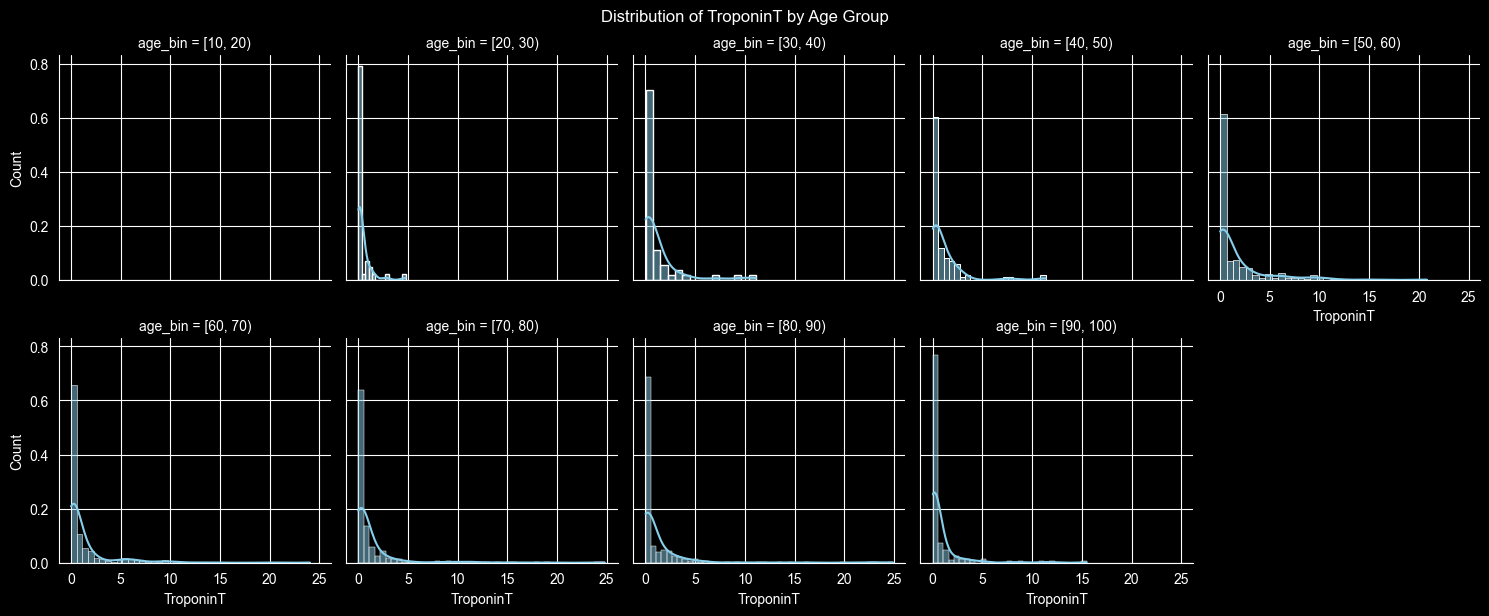

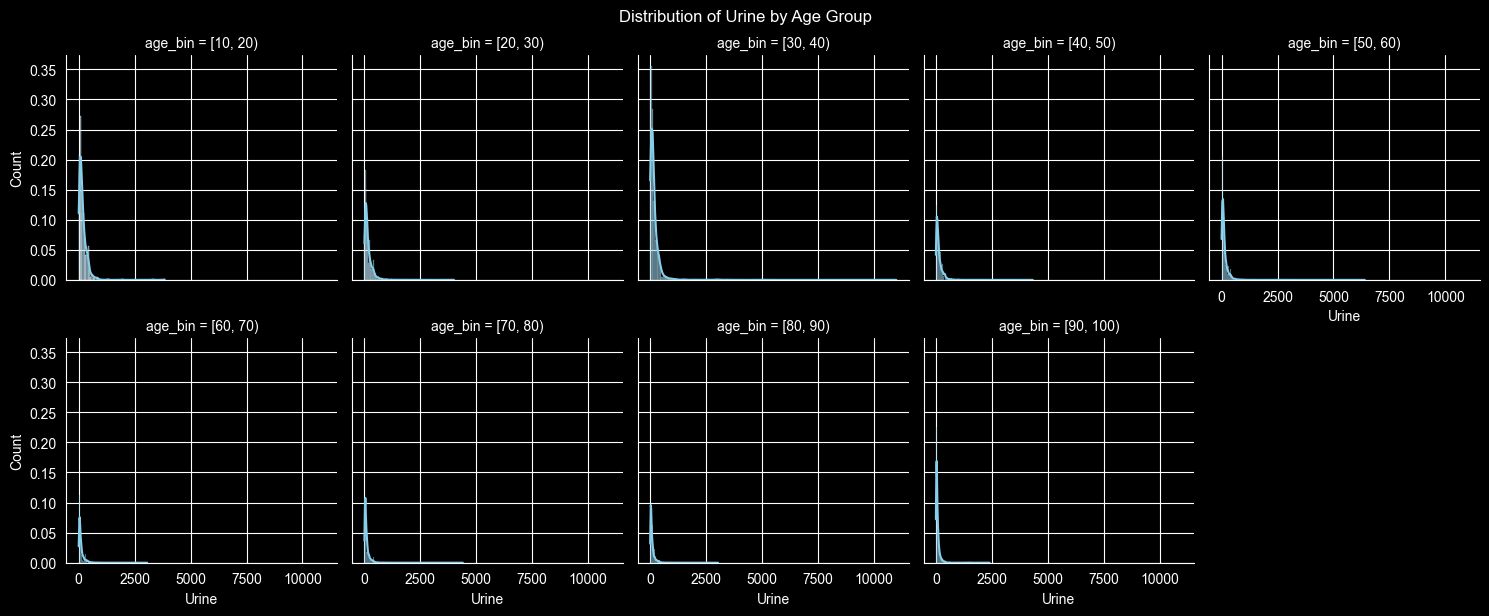

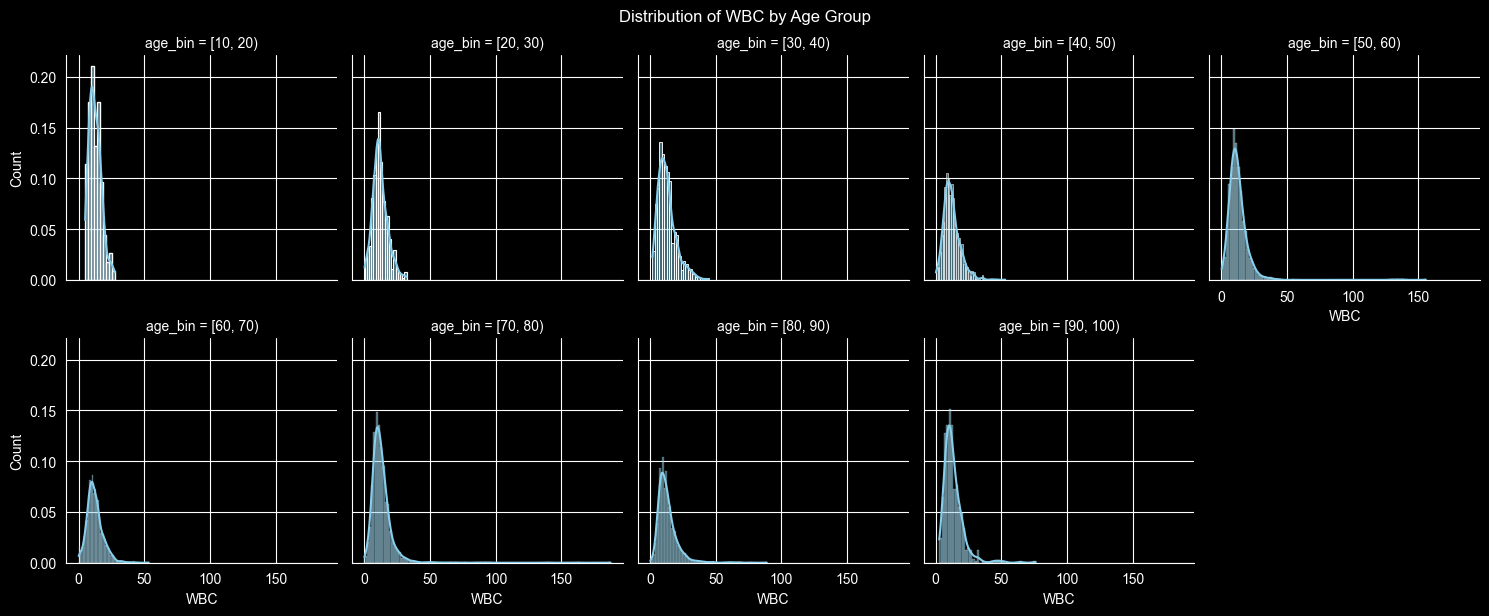

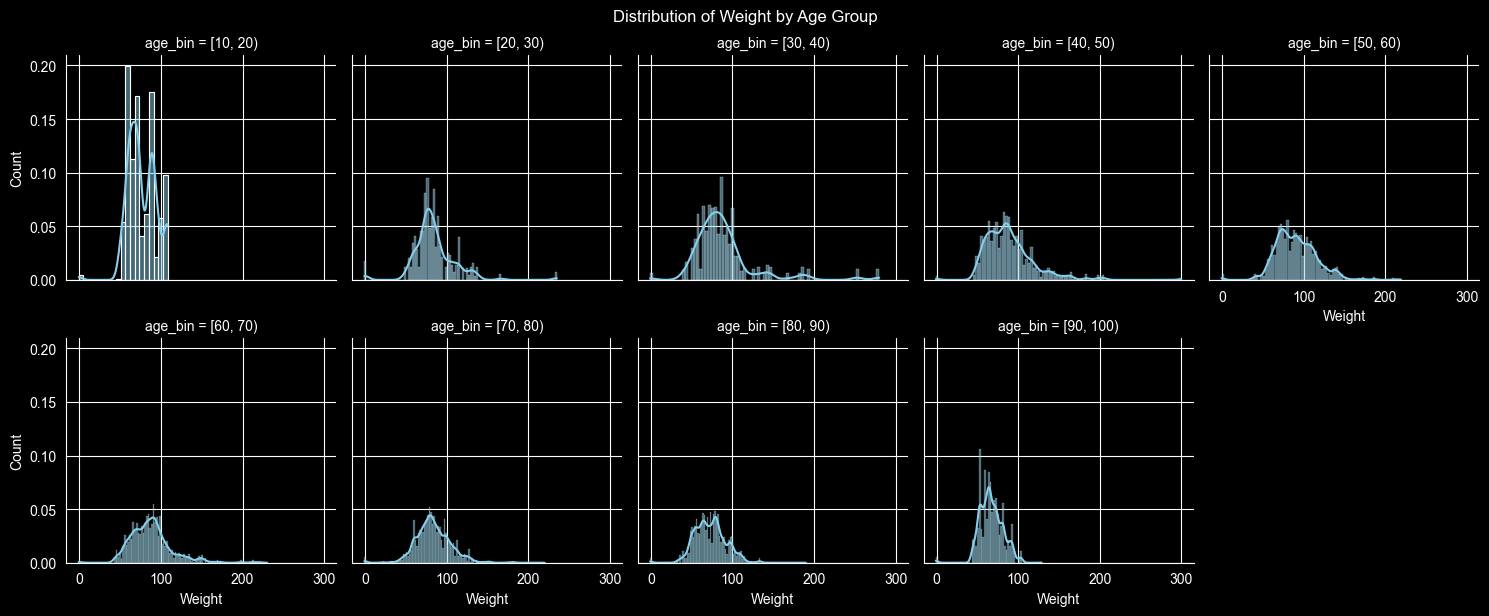

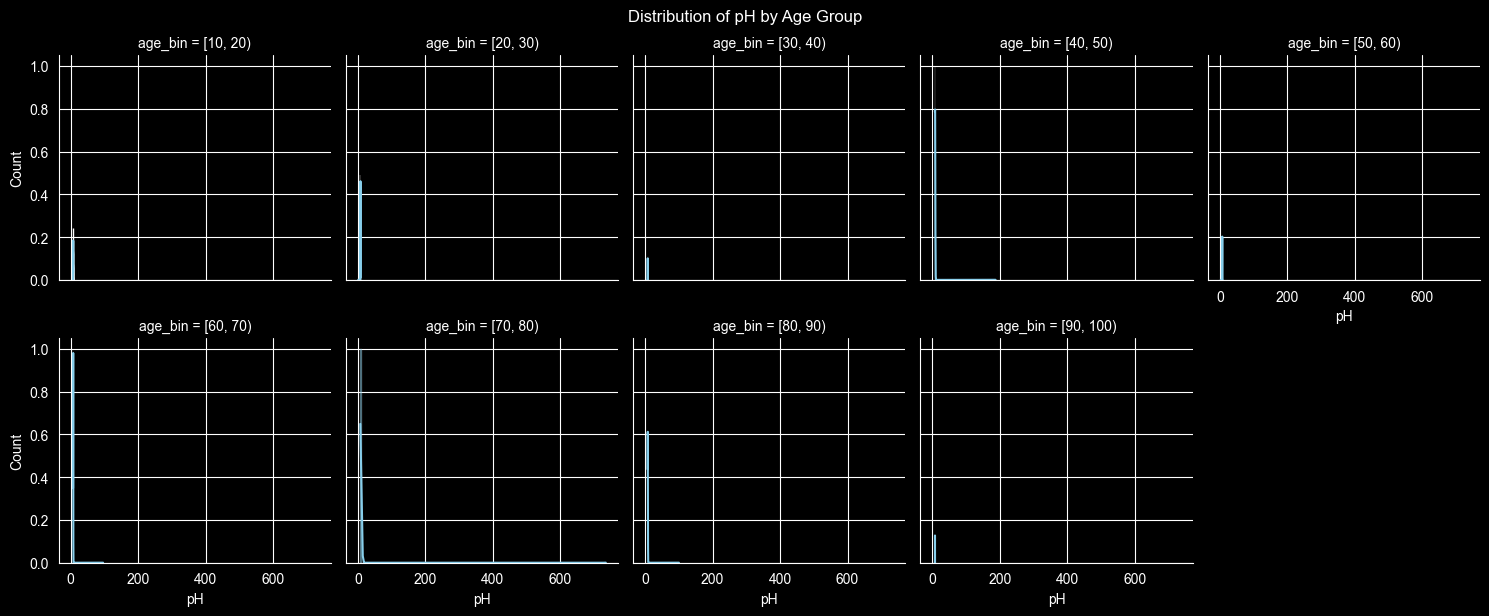

In [29]:
#Create the 10 year bins for ages
df_a = pd.read_parquet("processed/set_a.parquet")

df_a = add_age_bin(df_a)

mean_vars_df = df_a.groupby('age_bin', observed=False)[DYNAMIC_VARS].mean()
print(mean_vars_df)

#Plot for difference
import seaborn as sns
import matplotlib.pyplot as plt

# We loop through each variable you want to study
for var in DYNAMIC_VARS:
    # Create a "Grid" where each row/column is an age bin
    g = sns.FacetGrid(df_a, col="age_bin", col_wrap=5, sharex=True)

    # Map a histogram onto every square in that grid
    g.map(sns.histplot, var, kde=True, stat="probability", color="skyblue")

    g.set_axis_labels(var, "Count")
    g.fig.suptitle(f"Distribution of {var} by Age Group", y=1.02)
    plt.show()


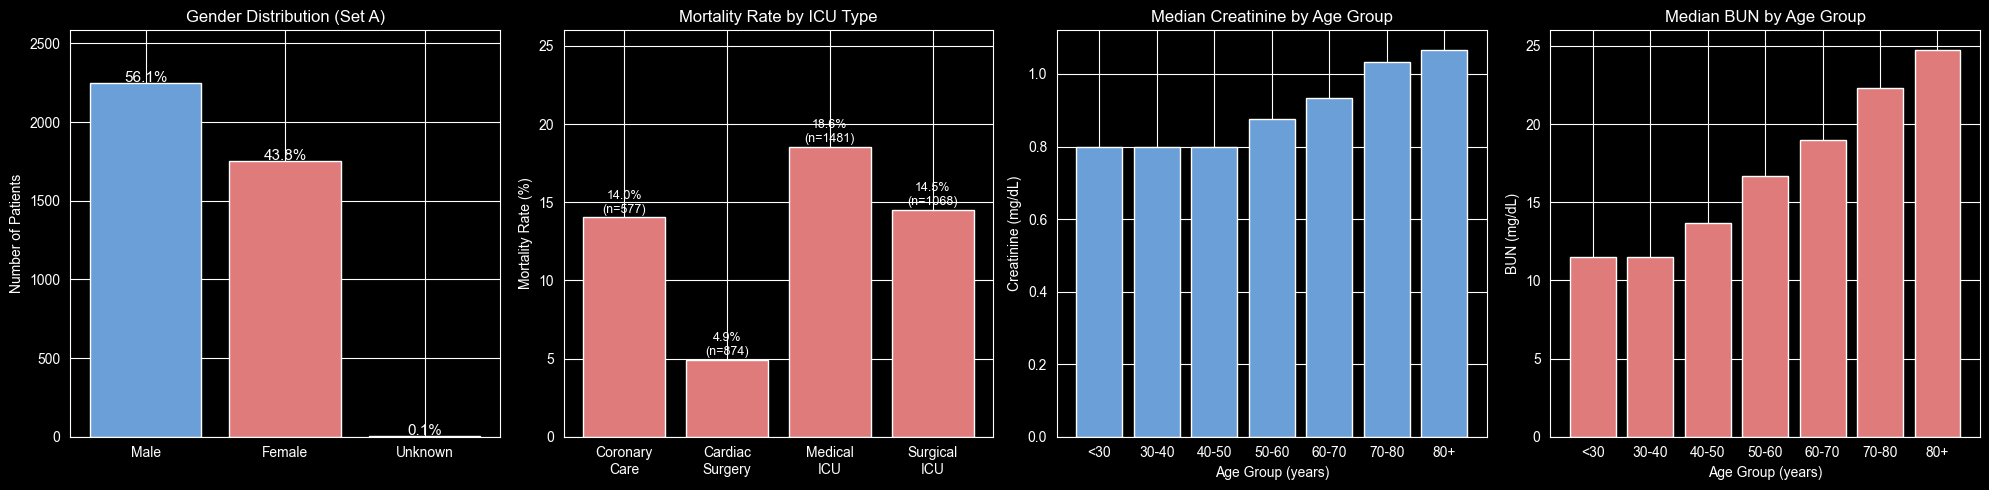

In [30]:
# Load raw set-a parquet + ICUType from patients_static
df_a = pd.read_parquet("processed/set_a.parquet")
patients_static_a, _ = load_cohort("set-a")

# One row per patient with static info
patient_info = df_a[df_a["hour"] == 0][["RecordID", "Age", "Gender", "In-hospital_death"]].copy()
patient_info = patient_info.merge(
    patients_static_a[["ICUType"]].reset_index(), on="RecordID", how="left"
)

ICU_LABELS = {1: "Coronary\nCare", 2: "Cardiac\nSurgery", 3: "Medical\nICU", 4: "Surgical\nICU"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# ── Plot 1: Gender representation ────────────────────────────────────────────
gender_counts = patient_info["Gender"].map({0: "Female", 1: "Male", -1: "Unknown"}).value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=["#6a9fd8", "#e07b7b", "#aaa"])
for i, (label, val) in enumerate(gender_counts.items()):
    pct = val / gender_counts.sum() * 100
    axes[0].text(i, val + 10, f"{pct:.1f}%", ha="center", fontsize=11)
axes[0].set_title("Gender Distribution (Set A)", fontsize=12)
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, gender_counts.max() * 1.15)

# ── Plot 2: Mortality rate by ICU type ───────────────────────────────────────
mortality_by_icu = (
    patient_info.groupby("ICUType")["In-hospital_death"]
    .agg(["mean", "count"]).reset_index()
)
mortality_by_icu["label"] = mortality_by_icu["ICUType"].map(ICU_LABELS)
bars = axes[1].bar(mortality_by_icu["label"], mortality_by_icu["mean"] * 100, color="#e07b7b")
for bar, (_, row) in zip(bars, mortality_by_icu.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%\n(n={int(row['count'])})", ha="center", fontsize=9)
axes[1].set_title("Mortality Rate by ICU Type", fontsize=12)
axes[1].set_ylabel("Mortality Rate (%)")
axes[1].set_ylim(0, mortality_by_icu["mean"].max() * 140)

# ── Age bins + per-patient mean labs ─────────────────────────────────────────
lab_per_patient = df_a.groupby("RecordID")[["Creatinine", "BUN"]].mean().reset_index()
patient_info2 = patient_info.merge(lab_per_patient, on="RecordID", how="left")
patient_info2 = patient_info2[patient_info2["Age"] > 0]  # remove sentinel -1

age_bins   = [0, 30, 40, 50, 60, 70, 80, 120]
age_labels = ["<30", "30-40", "40-50", "50-60", "60-70", "70-80", "80+"]
patient_info2["age_bin"] = pd.cut(patient_info2["Age"], bins=age_bins, labels=age_labels)
age_labs = patient_info2.groupby("age_bin", observed=True)[["Creatinine", "BUN"]].median()

x = np.arange(len(age_labs))

# ── Plot 3: Creatinine by age ─────────────────────────────────────────────────
axes[2].bar(x, age_labs["Creatinine"], color="#6a9fd8")
axes[2].set_xticks(x)
axes[2].set_xticklabels(age_labs.index)
axes[2].set_title("Median Creatinine by Age Group", fontsize=12)
axes[2].set_xlabel("Age Group (years)")
axes[2].set_ylabel("Creatinine (mg/dL)")

# ── Plot 4: BUN by age ───────────────────────────────────────────────────────
axes[3].bar(x, age_labs["BUN"], color="#e07b7b")
axes[3].set_xticks(x)
axes[3].set_xticklabels(age_labs.index)
axes[3].set_title("Median BUN by Age Group", fontsize=12)
axes[3].set_xlabel("Age Group (years)")
axes[3].set_ylabel("BUN (mg/dL)")

plt.tight_layout()
plt.savefig("processed/q1_2_demographic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Q1.3 Preprocess data for Machine Learning

In [31]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, StandardScaler

# ── 1. Load the parquet grids ────────────────────────────────────────────────
df_train = pd.read_parquet("processed/set_a.parquet")
df_val   = pd.read_parquet("processed/set_b.parquet")
df_test  = pd.read_parquet("processed/set_c.parquet")

# Expected to be defined earlier:
# DYNAMIC_VARS, STATIC_VARS
FEATURE_COLS = DYNAMIC_VARS + STATIC_VARS

ROBUST_COLS = [
    "ALP", "ALT", "AST", "BUN", "Bilirubin", "Creatinine", "Lactate", "PaO2",
    "TroponinI", "TroponinT", "Urine",
]

BINARY_COLS = ["MechVent"]
GENDER_COLS = ["Gender"]

# Columns scaled with StandardScaler
STANDARD_COLS = [
    c for c in FEATURE_COLS
    if c not in ROBUST_COLS + BINARY_COLS + GENDER_COLS
]

print(f"RobustScaler  ({len(ROBUST_COLS)}):   {ROBUST_COLS}")
print(f"Binary -0.5   ({len(BINARY_COLS)}):   {BINARY_COLS}")
print(f"StandardScaler({len(STANDARD_COLS)}): {STANDARD_COLS}")
print(f"Unscaled      ({len(GENDER_COLS)}):   {GENDER_COLS}")

# ── 2. Fix known data quality issues before imputation ───────────────────────
for df in [df_train, df_val, df_test]:
    # MechVent: NaN means off
    if "MechVent" in df.columns:
        df["MechVent"] = df["MechVent"].fillna(0)

    # pH cleanup
    if "pH" in df.columns:
        df.loc[df["pH"] > 100, "pH"] = df.loc[df["pH"] > 100, "pH"] / 100
        df.loc[(df["pH"] < 6.5) | (df["pH"] > 8.5), "pH"] = np.nan

    # Sentinel -1 -> NaN for static numeric fields
    for col in ["Age", "Height", "Weight"]:
        if col in df.columns:
            df.loc[df[col] == -1, col] = np.nan

# ── 3. Forward-fill imputation (per patient, causal) ─────────────────────────
# Do not ffill Gender; keep it as-is
FFILL_COLS = [c for c in FEATURE_COLS if c != "Gender" and c in df_train.columns]

def forward_fill_patient(df):
    df = df.copy()
    df[FFILL_COLS] = (
        df.groupby("RecordID")[FFILL_COLS]
          .transform(lambda s: s.ffill())
    )
    return df

print("Applying forward-fill imputation...")
df_train = forward_fill_patient(df_train)
df_val   = forward_fill_patient(df_val)
df_test  = forward_fill_patient(df_test)

# ── 4. Fill remaining NaN with training-set medians ──────────────────────────
# Group by ICUType, Gender, age_bin; exclude grouping cols from imputation targets
GROUP_COLS = ["ICUType", "Gender", "age_bin"]


df_train = add_age_bin(df_train)
df_val   = add_age_bin(df_val)
df_test  = add_age_bin(df_test)

# Columns to impute with medians
IMPUTE_COLS = [
    c for c in FEATURE_COLS
    if c not in GROUP_COLS and c in df_train.columns
]

# Most specific fallback: ICUType + Gender + age_bin
train_medians = (
    df_train.groupby(GROUP_COLS, dropna=False, observed=False)[IMPUTE_COLS]
    .median()
    .reset_index()
)

# Less specific fallback: ICUType + Gender
fallback_icu_gender = (
    df_train.groupby(["ICUType", "Gender"], dropna=False)[IMPUTE_COLS]
    .median()
    .reset_index()
)

# Final fallback: global train medians
fallback_global = df_train[IMPUTE_COLS].median()

def fillna_with_medians(df):
    df = df.copy()

    # Merge subgroup medians
    med = train_medians.rename(columns={c: f"{c}_med" for c in IMPUTE_COLS})
    df = df.merge(med, on=["ICUType", "Gender", "age_bin"], how="left")

    # Merge weaker fallback medians
    med2 = fallback_icu_gender.rename(columns={c: f"{c}_med2" for c in IMPUTE_COLS})
    df = df.merge(med2, on=["ICUType", "Gender"], how="left")

    # Fill NaNs using fallback chain
    for col in IMPUTE_COLS:
        df[col] = df[col].fillna(df[f"{col}_med"])
        df[col] = df[col].fillna(df[f"{col}_med2"])
        df[col] = df[col].fillna(fallback_global[col])

    # Clean helper columns
    helper_cols = (
        ["age_bin"] +
        [f"{c}_med" for c in IMPUTE_COLS] +
        [f"{c}_med2" for c in IMPUTE_COLS]
    )
    df = df.drop(columns=helper_cols, errors="ignore")

    return df

print("Filling remaining NaN with training-set medians...")
df_train = fillna_with_medians(df_train)
df_val   = fillna_with_medians(df_val)
df_test  = fillna_with_medians(df_test)

# Gender: remaining NaN -> -1 (unknown)
if "Gender" in df_train.columns:
    df_train["Gender"] = df_train["Gender"].fillna(-1)
    df_val["Gender"]   = df_val["Gender"].fillna(-1)
    df_test["Gender"]  = df_test["Gender"].fillna(-1)

print(f"NaN remaining after imputation — train: {df_train[FEATURE_COLS].isna().sum().sum()}")
print(f"NaN remaining after imputation — val:   {df_val[FEATURE_COLS].isna().sum().sum()}")
print(f"NaN remaining after imputation — test:  {df_test[FEATURE_COLS].isna().sum().sum()}")

# ── 5. Fit scalers on training set only ──────────────────────────────────────
robust_scaler   = RobustScaler()
standard_scaler = StandardScaler()

robust_fit_cols = [c for c in ROBUST_COLS if c in df_train.columns]
standard_fit_cols = [c for c in STANDARD_COLS if c in df_train.columns]

robust_scaler.fit(df_train[robust_fit_cols])
standard_scaler.fit(df_train[standard_fit_cols])

# ── 6. Apply scaling ──────────────────────────────────────────────────────────
def apply_scaling(df):
    df = df.copy()

    if robust_fit_cols:
        df[robust_fit_cols] = robust_scaler.transform(df[robust_fit_cols])

    if standard_fit_cols:
        df[standard_fit_cols] = standard_scaler.transform(df[standard_fit_cols])

    for col in BINARY_COLS:
        if col in df.columns:
            df[col] = df[col] - 0.5   # {0,1} -> {-0.5, 0.5}

    # Gender left unchanged: 0, 1, -1
    return df

df_train_scaled = apply_scaling(df_train)
df_val_scaled   = apply_scaling(df_val)
df_test_scaled  = apply_scaling(df_test)

# ── 7. Save ───────────────────────────────────────────────────────────────────
os.makedirs("processed", exist_ok=True)

df_train_scaled.to_parquet("processed/set_a_processed.parquet", index=False)
df_val_scaled.to_parquet("processed/set_b_processed.parquet", index=False)
df_test_scaled.to_parquet("processed/set_c_processed.parquet", index=False)

with open("processed/scalers.pkl", "wb") as f:
    pickle.dump(
        {
            "robust": robust_scaler,
            "standard": standard_scaler,
            "robust_cols": robust_fit_cols,
            "standard_cols": standard_fit_cols,
        },
        f
    )

print("\nScaling summary (train set, first hour):")
sample = df_train_scaled[df_train_scaled["RecordID"] == df_train_scaled["RecordID"].iloc[0]].iloc[0]
print(sample[["HR", "Temp", "ALP", "BUN", "MechVent", "Gender", "Age"]].to_dict())

print("\nSaved processed datasets to processed/")

RobustScaler  (11):   ['ALP', 'ALT', 'AST', 'BUN', 'Bilirubin', 'Creatinine', 'Lactate', 'PaO2', 'TroponinI', 'TroponinT', 'Urine']
Binary -0.5   (1):   ['MechVent']
StandardScaler(29): ['Albumin', 'Cholesterol', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'MAP', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'WBC', 'Weight', 'pH', 'Age', 'Height', 'StaticWeight', 'ICUType']
Unscaled      (1):   ['Gender']
Applying forward-fill imputation...
Filling remaining NaN with training-set medians...
NaN remaining after imputation — train: 0
NaN remaining after imputation — val:   0
NaN remaining after imputation — test:  0

Scaling summary (train set, first hour):
{'HR': -0.14860231066787039, 'Temp': 0.07393706094820716, 'ALP': 0.6666666666666666, 'BUN': -0.375, 'MechVent': -0.5, 'Gender': 0.0, 'Age': -0.5836121192506702}

Saved processed datasets to processed/


Group	Variables	Method	Why
Skewed labs	ALP, ALT, AST, BUN, Lactate, TroponinI/T, Urine, Creatinine	RobustScaler (median + IQR)	Extreme right-skew and outliers — mean/std would be dominated by rare extreme values
Continuous	HR, Temp, BP, pH, GCS, Na, K, etc.	StandardScaler (mean + std)	Roughly symmetric distributions, well-behaved for zero-centering
Binary	MechVent	subtract 0.5	Maps {0,1} → {-0.5, 0.5}, centered around 0 without distorting the binary nature
Categorical	Gender	unchanged (0, 1, -1)	Not a continuous variable — scaling would imply false ordinal relationships